# Кредитный скоринг

### Постановка задачи:

* выявить и обработать пропущенные значения и значения-заглушки;
* изучить основные характеристики признаков и их распределения;
* выявить некорректные значения и аномальные наблюдения;
* определить и обработать выбросы;
* при необходимости восстановить некорректные значения на основе имеющейся информации о клиенте;
* оценить влияние проведённой очистки на качество и структуру данных

## Общий обзор

In [1]:
#загрузим библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
sns.set_theme(style="whitegrid")

In [2]:
#считаем датасет
credit_df = pd.read_csv('../data/train.csv', index_col='ID')

C:\Users\79659\AppData\Local\Temp\ipykernel_11900\2268535609.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_df = pd.read_csv('../data/train.csv', index_col='ID')


In [3]:
#отобразим
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [4]:
# Проверим уникальные значения в столбце со смешанными типами данных
mixed_col = credit_df.columns[25]

print(f'Column: {mixed_col}')
print(credit_df[mixed_col].unique())

Column: Monthly_Balance
['312.49408867943663' '284.62916249607184' '331.2098628537912' ...
 516.8090832742814 319.1649785257098 393.6736955618808]


In [5]:
credit_df['Monthly_Balance'].value_counts(dropna=False)

Monthly_Balance
NaN                                 1200
__-333333333333333333333333333__       9
484.5912142650067                      1
393.673696                             1
312.49408867943663                     1
                                    ... 
300.008498                             1
396.997157                             1
368.154976                             1
412.669312                             1
432.559318                             1
Name: count, Length: 98793, dtype: int64

In [6]:
credit_df.loc[credit_df['Monthly_Balance'] == '__-333333333333333333333333333__']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x367f,CUS_0x9885,February,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,Standard,113.98,34.826541,11 Years and 6 Months,Yes,145.544320,201.1429928919469,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Standard
0xaf63,CUS_0x5a90,February,Scuffhamq,45,264-53-1943,Engineer,29728.31,2551.359167,3,4,...,Good,917.0,38.198076,31 Years and 9 Months,No,34.496445,198.6115126951797,Low_spent_Large_value_payments,__-333333333333333333333333333__,Good
0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.93,2572.410833,1,6,...,Good,860.97,40.634250,19 Years and 5 Months,No,43.727774,79.07180674947499,High_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xe66c,CUS_0x85e9,March,Anna Driveri,45,288-62-7562,_______,20929.295_,1704.107917,5,3,...,_,858.09,33.943626,21 Years and 7 Months,No,13798.000000,220.30455197823662,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xf84c,CUS_0x2b77,July,Longstretho,21,006-36-0111,Doctor,15167.62,1471.968333,4,5,...,Good,847.03,28.541848,NaN,NM,9.930809,128.87587207680795,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.68,7811.223333,3,4,...,Standard,820.52,39.089475,20 Years and 10 Months,Yes,54.219664,NaN,High_spent_Large_value_payments,__-333333333333333333333333333__,Standard
0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.59,NaN,3,4,...,Standard,2441.47,29.878716,12 Years and 11 Months,Yes,61.525140,394.8939566733383,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fbd8,CUS_0x41bf,July,Doeringq,44,693-64-7611,Journalist,61990.52,4900.876667,10,10,...,Bad,3618.91,37.718591,13 Years and 8 Months,NM,355.143396,194.28348839148083,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fdd1,CUS_0x2f7e,August,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.420000,4,7,...,_,859.77,28.442867,31 Years and 9 Months,No,167.043910,549.7661392945339,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Poor


В признаке 'Monthly_Balance'  есть некорректные значения, которые вызывают предупреждения Pandas. Они будут обработаны позже.

In [7]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Name                      90015 non-null   object 
 3   Age                       100000 non-null  object 
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  object 
 7   Monthly_Inhand_Salary     84998 non-null   float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  object 
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  

В датафрейме 26 признаков и 1 целевая переменная и пропуски 8 столбцах.


- 0   ID                         - идентификатор
- 1   Customer_ID               - идентификатор клиента 
-  2   Month                     - месяц 
-  3   Name                      - имя 
- 4   Age                       - возраст 
- 5   SSN                       - номер социального страхования
- 6   Occupation                - род деятельности 
- 7   Annual_Income             - ежегодный доход 
- 8   Monthly_Inhand_Salary     - ежемесячный доход без учета налогов
- 9   Num_Bank_Accounts         - количество банковских аккаунтов
- 10  Num_Credit_Card           - количество кредитных карт
- 11  Interest_Rate             - процентная ставка 
- 12  Num_of_Loan               - количество кредитов 
- 13  Type_of_Loan              - тип кредита 
- 14  Delay_from_due_date       - задержка срока платежа
- 15  Num_of_Delayed_Payment    - количество задержек
- 16  Changed_Credit_Limit      - изменение кредитного лимита
- 17  Num_Credit_Inquiries      - количество запросов кредита
- 18  Credit_Mix                - кредит мик
- 19  Outstanding_Debt          - непогашенный долг
- 20  Credit_Utilization_Ratio  - коэффициент использования кредита
- 21  Credit_History_Age        - протяженности кредитной истории 
- 22  Payment_of_Min_Amount     - минимальный платеж 
- 23  Total_EMI_per_month       - равномерные ежемесячные платежи
- 24  Amount_invested_monthly   - ежемесячные инвестиции 
- 25  Payment_Behaviour         - платежное поведение
- 26  Monthly_Balance           - ежемесячный баланс 
- 27  Credit_Score              - кредитный рейтинг

Посмотрим статистики по разным столбцам в зависимости от типа и проверим на дубликаты.

In [8]:
print(f'Количество дубликатов: {credit_df.duplicated().sum()}')

Количество дубликатов: 0


In [9]:
credit_df.select_dtypes(include='number').describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [10]:
credit_df.select_dtypes(include='object').describe()

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


* У ряда признаков с числовыми значениями тип данных определён как object, что требует предварительного преобразования типов.
* В данных присутствуют выбросы, аномальные и некорректные значения.
* Данные требуют преобразования, очистки и приведения признаков к корректным типам.
* Анализ и очистка будут проводиться отдельно для каждого признака с учётом его природы и оценкой распределения и статистики, где возможно.
* При обработке данных будет учитываться согласованность значений внутри каждого Customer_ID, что позволит выявлять некорректные значения и, где возможно, восстанавливать их на основе других наблюдений того же клиента.


## Анализ признаков

In [11]:
credit_df['Name'] = (
    credit_df.groupby('Customer_ID')['Name']
    .transform(lambda x: x.ffill().bfill())
)

In [12]:
credit_df.groupby('Customer_ID')['Name'].nunique().loc[lambda x: x > 1]

Series([], Name: Name, dtype: int64)

В датафрейме есть два признака идентификатора: Customer-ID и ID. Рассмотрим их.

In [13]:
print(f'Количество уникальных значений для Customer-ID: {len(credit_df['Customer_ID'].unique())}')
print(f'Количество пропусков для Custome-ID {credit_df['Customer_ID'].isna().sum()}')

Количество уникальных значений для Customer-ID: 12500
Количество пропусков для Custome-ID 0


In [14]:
print(f'Есть ли пропуски в индексе: {credit_df.index.hasnans}')
print(f'Содержатся ли в индексе уникальные значения: {credit_df.index.nunique()}')

Есть ли пропуски в индексе: False
Содержатся ли в индексе уникальные значения: 100000


**Выводы по признакам Custome-ID и ID**
- Датафрейм содержит данные о 12500 клиентах.
- В качестве индекса используется идентификтор - ID, уникальный для каждой строки. Он не информативен и его можно удалить без потери информации.
- Признак Custome-ID служит для идентификации клиента 

In [15]:
#посмотрим, сколько у нас уникальных значений в категории месяц
print(f'уникальный значений в категории месяц: {len(credit_df["Month"].unique())}')
print(*credit_df['Month'].unique(), sep='\n')

уникальный значений в категории месяц: 8
January
February
March
April
May
June
July
August


**Выводы по признаку Month**
- В датафрейме представленные данные 12500 клиентов за 8 месяцев.

In [16]:
#так как часть данных вметсо числовых форматов представлена в object напишем функцию для удаления нечисловых символов из количественных данных
def numeric(x):
    x = list(x)
    for i in x:
        if i in '.1234567890':
            continue
        else:
            x.remove(i)
    return ''.join(x)

In [17]:
#применим функцию numeric к столбцу age
credit_df['Age'] = credit_df['Age'].apply(numeric)
#поменяем тип данных категори возраст на int и посмотрим их распределение
credit_df['Age'] = credit_df['Age'].astype(int)

In [18]:
#проверим работу функции
credit_df['Age']

ID
0x1602      23
0x1603      23
0x1604     500
0x1605      23
0x1606      23
          ... 
0x25fe9     25
0x25fea     25
0x25feb     25
0x25fec     25
0x25fed     25
Name: Age, Length: 100000, dtype: int64

In [19]:
print(f'Количество пропусков в графе возраст {credit_df['Age'].isna().sum()}')

Количество пропусков в графе возраст 0


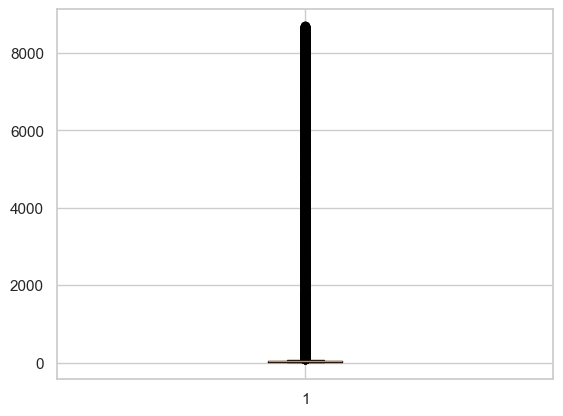

In [20]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [21]:
credit_df['Age'].describe()

count    100000.000000
mean        119.509700
std         684.757313
min          14.000000
25%          25.000000
50%          34.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Статистики и боксплот показывают, что у нас скошенное распределение и большой хвост выбросов. Почистим данные: нужно удалить клиентов, чей возраст выходит за диапазон от нуля до сто десяти. Также проверить, чтобы у каждого клиента был один возраст или разница между возрастами была не более одного года, так как в датафрейме представлены данные за один год.

In [22]:
#отфильтруем возраст клиентов от 0 до 100, чтобы избавится от выбросов
age_df = credit_df[(credit_df['Age'] > 0) & (credit_df['Age'] <= 110)][['Age', 'Customer_ID']]
age_df = age_df.reset_index(drop=True).drop_duplicates()
age_df

,Age,Customer_ID
0,23,CUS_0xd40
7,28,CUS_0x21b1
15,34,CUS_0x2dbc
23,54,CUS_0xb891
25,55,CUS_0xb891
...,...,...
97207,50,CUS_0xaf61
97210,28,CUS_0x8600
97217,29,CUS_0x8600
97218,24,CUS_0x942c


In [23]:
age_df.groupby('Customer_ID')['Age'].nunique().sort_values(ascending=False).head()

Customer_ID
CUS_0xffd     2
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0xfb8     2
Name: Age, dtype: int64

In [24]:
problem_clients = age_df.groupby('Customer_ID')['Age'].nunique()
problem_clients = problem_clients[problem_clients > 1]

print(problem_clients)

Customer_ID
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x1013    2
             ..
CUS_0xfe5     2
CUS_0xff4     2
CUS_0xff6     2
CUS_0xffc     2
CUS_0xffd     2
Name: Age, Length: 7205, dtype: int64


In [25]:
age_df.groupby('Customer_ID')['Age'].unique().loc[problem_clients.index]

Customer_ID
CUS_0x1000    [17, 18]
CUS_0x1009    [25, 26]
CUS_0x100b    [18, 19]
CUS_0x1011    [43, 44]
CUS_0x1013    [43, 44]
                ...   
CUS_0xfe5     [37, 38]
CUS_0xff4     [36, 37]
CUS_0xff6     [18, 19]
CUS_0xffc     [17, 18]
CUS_0xffd     [29, 30]
Name: Age, Length: 7205, dtype: object

Как мы можем видеть возраст у проблемных клиентов отличается на 1, скорее всего у клиента было день рождение. Соберем тех клиентов, у кого разница в дне рождении составляет больше 1 года.

In [26]:
(
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
    .value_counts()
)

Age
1     7198
0     5295
68       2
71       1
67       1
61       1
63       1
44       1
Name: count, dtype: int64

In [27]:
age_diff = (
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
)

problem_ids = age_diff[age_diff > 1]

print(problem_ids)

Customer_ID
CUS_0x1dd3    71
CUS_0x3b9a    68
CUS_0x4b64    67
CUS_0x51cb    61
CUS_0x7e94    63
CUS_0xc24a    68
CUS_0xdc8     44
Name: Age, dtype: int64


In [28]:
age_df[
    age_df['Customer_ID'].isin(problem_ids.index)
].sort_values('Customer_ID')

,Age,Customer_ID
76379,24,CUS_0x1dd3
76383,95,CUS_0x1dd3
28505,32,CUS_0x3b9a
28509,100,CUS_0x3b9a
30437,102,CUS_0x4b64
30438,35,CUS_0x4b64
54630,48,CUS_0x51cb
54635,109,CUS_0x51cb
37191,95,CUS_0x7e94
37192,32,CUS_0x7e94


In [29]:
credit_df.loc[
    credit_df['Customer_ID'].isin(problem_ids.index),
    ['Customer_ID', 'Name', 'Age']
].sort_values(['Customer_ID', 'Age'])

,Customer_ID,Name,Age
ID,,,
0x1e252,CUS_0x1dd3,Gerryg,24
0x1e253,CUS_0x1dd3,Gerryg,24
0x1e254,CUS_0x1dd3,Gerryg,24
0x1e255,CUS_0x1dd3,Gerryg,24
0x1e257,CUS_0x1dd3,Gerryg,24
0x1e258,CUS_0x1dd3,Gerryg,24
0x1e259,CUS_0x1dd3,Gerryg,24
0x1e256,CUS_0x1dd3,Gerryg,95
0xc1c2,CUS_0x3b9a,Seetharamanw,32


In [30]:
#заменим некорекктные значения возраста
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x1dd3', 'Age'] = 24
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x3b9a', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x4b64', 'Age'] = 35
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x51cb', 'Age'] = 48
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x7e94', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xc24a', 'Age'] = 31
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xdc8', 'Age'] = 51


In [31]:
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [32]:
rate_of_incorret_age = (1 - len(credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)])/len(credit_df))
print(f'Доля некорректных данных по возрасту: {rate_of_incorret_age:.2%}')

Доля некорректных данных по возрасту: 2.77%


Мы можем удалить некорректные данные, так как их величина не значительна.

In [33]:
credit_df = credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)]
credit_df = credit_df.copy()

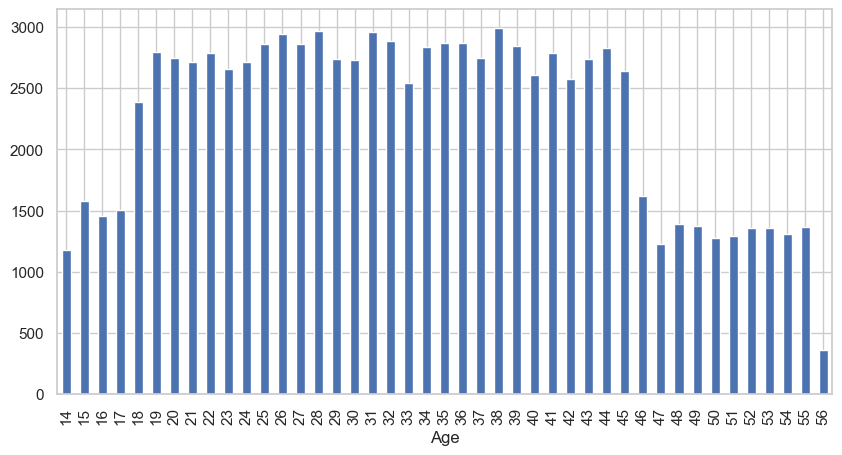

In [34]:
age_group = credit_df.groupby(by='Age')['Age'].count()
age_group.plot(kind='bar', grid=True, figsize=(10, 5))
plt.show()

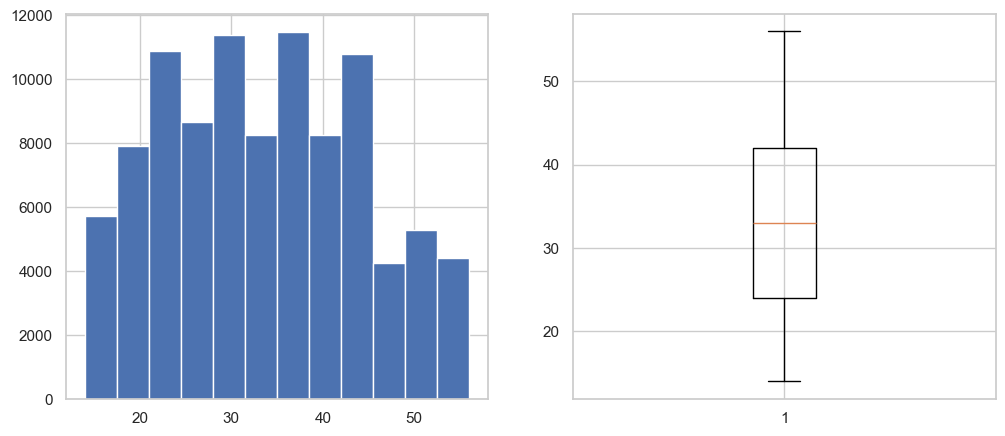

In [35]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Age'], bins=12)
ax2.boxplot(x='Age', data=credit_df)
plt.show()

In [36]:
credit_df['Age'].describe()

count    97227.000000
mean        33.320364
std         10.769517
min         14.000000
25%         24.000000
50%         33.000000
75%         42.000000
max         56.000000
Name: Age, dtype: float64

**Выводы по признаку Age** 
- Данные очищены от некорректных значений возраста: значений меньше 0 и превышающих 110 лет.
- Исправлены значения, возникшие вследствие некорректного представления возраста в исходных данных.
- После очистки средний возраст клиента составляет 33 года.
- Возраст клиентов в очищенном датасете находится в диапазоне от 14 до 56 лет.

In [37]:
#проверим данные по графе SSN
credit_df.groupby('SSN')['Name'].nunique().sort_values(ascending=False).head()

SSN
#F%$D@*&8      4124
998-47-8892       1
998-30-4976       1
000-63-0442       1
999-99-3421       1
Name: Name, dtype: int64

У 3809 строк значение похоже на ошибку или заглушку. Попробуем восстановить это значение из данных.

In [38]:
df_snn = credit_df.loc[credit_df['SSN'] == '#F%$D@*&8']

In [39]:
df_snn['Customer_ID']

ID
0x1609      CUS_0xd40
0x162b     CUS_0xb891
0x164d     CUS_0x284a
0x1650     CUS_0x284a
0x1694     CUS_0x3e45
              ...    
0x25f70    CUS_0x1619
0x25f98    CUS_0xad4f
0x25fa0    CUS_0x51b3
0x25fc2     CUS_0xf16
0x25fde    CUS_0x8600
Name: Customer_ID, Length: 5408, dtype: object

In [40]:
credit_df_filtered = credit_df[credit_df['Customer_ID'].isin(df_snn['Customer_ID'])]
credit_df_filtered

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fdd,CUS_0x8600,April,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,30.614953,5 Years and 11 Months,Yes,60.964772,43.72461709437765,High_spent_Large_value_payments,328.301277,Standard
0x25fde,CUS_0x8600,May,Sarah McBridec,28,#F%$D@*&8,Architect,20002.88,1929.906667,10,8,...,_,3571.7,28.508250,6 Years and 0 Months,Yes,60.964772,213.97800979403817,Low_spent_Small_value_payments,208.047884,Standard
0x25fdf,CUS_0x8600,June,Sarah McBridec,28,031-35-0942,_______,20002.88,1929.906667,10,8,...,Bad,3571.7,33.359987,6 Years and 1 Months,Yes,60.964772,74.36660309585342,!@9#%8,307.659291,Standard


In [41]:
credit_df_filtered.groupby('Customer_ID')['SSN'].nunique().sort_values(ascending=False)

Customer_ID
CUS_0xff3     2
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x102e    2
             ..
CUS_0x10eb    2
CUS_0x10d7    2
CUS_0x10ac    2
CUS_0x10aa    2
CUS_0x109d    2
Name: SSN, Length: 4510, dtype: int64

In [42]:
ssn_counts = credit_df.groupby('Customer_ID')['SSN'].nunique()

ssn_counts_gt2 = ssn_counts[ssn_counts > 2].sort_values(ascending=False)

In [43]:
mask = credit_df['Customer_ID'].isin(ssn_counts.index)

valid_ssn = (
    credit_df[mask & (credit_df['SSN'] != '#F%$D@*&8')]
    .groupby('Customer_ID')['SSN']
    .first()
)

In [44]:
mask = (
    credit_df['Customer_ID'].isin(valid_ssn.index) &
    (credit_df['SSN'] == '#F%$D@*&8')
)

credit_df.loc[mask, 'SSN'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_ssn)
)

In [45]:
#проверяем результат замены
credit_df['SSN'].nunique()

12500

**выводы по признаку SSN**
- Проведен анализ случаев появления значения-заглушки #F%$D@*&8.
- Установлено, что появление заглушки носит единичный характер и не является систематической проблемой данных.
- Для клиентов, у которых значение SSN было представлено заглушкой, проведена проверка других записей по Customer_ID.
- Заглушки были заменены на валидные значения SSN соответствующего клиента на основании согласованности данных внутри Customer_ID.

In [46]:
print(*credit_df['Occupation'].unique(), sep="\n")

Scientist
_______
Teacher
Engineer
Entrepreneur
Developer
Lawyer
Media_Manager
Doctor
Journalist
Manager
Accountant
Musician
Mechanic
Writer
Architect


Посмотрим пропуски в профессиях.

In [47]:
credit_df.groupby('Customer_ID')['Occupation'].nunique().sort_values(ascending=False)

Customer_ID
CUS_0x1026    2
CUS_0xfd1     2
CUS_0xfdf     2
CUS_0xfe3     2
CUS_0xfe4     2
             ..
CUS_0x61a3    1
CUS_0x102e    1
CUS_0x1032    1
CUS_0x1037    1
CUS_0x1038    1
Name: Occupation, Length: 12500, dtype: int64

In [48]:
credit_df_filtered = credit_df[
    credit_df['Customer_ID'].isin(
        credit_df.groupby('Customer_ID')['Occupation']
                 .nunique()
                 .loc[lambda x: x == 2]
                 .index
    )
]

In [49]:
credit_df_filtered

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good
0x1610,CUS_0x21b1,March,Rick Rothackerj,28,004-07-5839,Teacher,34847.84_,3037.986667,2,1385,...,_,605.03,33.224951,26 Years and 9 Months,No,18.816215,58.51597569589465,High_spent_Large_value_payments,466.46647639764313,Standard
0x1611,CUS_0x21b1,April,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,NaN,2,4,...,Good,605.03,39.182656,26 Years and 10 Months,No,18.816215,99.30622796053305,Low_spent_Medium_value_payments,465.6762241330048,Good
0x1612,CUS_0x21b1,May,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,...,Good,605.03,34.977895,26 Years and 11 Months,No,18.816215,130.11542024292334,Low_spent_Small_value_payments,444.8670318506144,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fdd,CUS_0x8600,April,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,30.614953,5 Years and 11 Months,Yes,60.964772,43.72461709437765,High_spent_Large_value_payments,328.301277,Standard
0x25fde,CUS_0x8600,May,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,28.508250,6 Years and 0 Months,Yes,60.964772,213.97800979403817,Low_spent_Small_value_payments,208.047884,Standard
0x25fdf,CUS_0x8600,June,Sarah McBridec,28,031-35-0942,_______,20002.88,1929.906667,10,8,...,Bad,3571.7,33.359987,6 Years and 1 Months,Yes,60.964772,74.36660309585342,!@9#%8,307.659291,Standard


In [50]:
valid_occupation = (
    credit_df[credit_df['Occupation'] != '_______']
    .groupby('Customer_ID')['Occupation']
    .first()
)

In [51]:
mask = credit_df['Occupation'] == '_______'

credit_df.loc[mask, 'Occupation'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_occupation)
)

In [52]:
credit_df

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [53]:
print(*credit_df['Occupation'].unique(), sep="\n")

Scientist
Teacher
Engineer
Entrepreneur
Developer
Lawyer
Media_Manager
Doctor
Journalist
Manager
Accountant
Musician
Mechanic
Writer
Architect


**выводы по признаку Occupation**
- заглушка "____" заменена на валидную профессию каждого клиента

In [54]:
#Annual Income
credit_df['Annual_Income'] = credit_df['Annual_Income'].apply(numeric)
credit_df['Annual_Income'] = credit_df['Annual_Income'].astype(float)

In [55]:
credit_df['Annual_Income'].describe()

count    9.722700e+04
mean     1.768399e+05
std      1.432660e+06
min      7.005930e+03
25%      1.946292e+04
50%      3.757975e+04
75%      7.281702e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

In [56]:
credit_df.loc[credit_df['Annual_Income'] == credit_df['Annual_Income'].max()]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x13104,CUS_0xcfc,July,Catherine Bosleyz,31,555-99-1654,Engineer,24198062.0,1135.525417,4,5,...,Good,672.49,34.790192,18 Years and 4 Months,No,46.388945,53.57386255067172,Low_spent_Large_value_payments,283.58973432257824,Good


In [57]:
credit_df[credit_df['Customer_ID'] == 'CUS_0xcfc']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x130fe,CUS_0xcfc,January,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,NaN,4,5,...,Good,672.49,37.008636,17 Years and 10 Months,No,46.388945,139.36742966998645,Low_spent_Small_value_payments,217.79616720326354,Good
0x130ff,CUS_0xcfc,February,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,Good,672.49,34.865078,17 Years and 11 Months,No,46.388945,69.4070447487928,Low_spent_Small_value_payments,287.7565521244572,Good
0x13100,CUS_0xcfc,March,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,_,672.49,32.991519,NaN,No,46.388945,65.97411958788724,Low_spent_Small_value_payments,291.1894772853627,Standard
0x13101,CUS_0xcfc,April,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,NaN,4,5,...,Good,672.49,37.551313,18 Years and 1 Months,No,46.388945,39.63190519155351,High_spent_Medium_value_payments,277.5316916816965,Good
0x13102,CUS_0xcfc,May,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,715,745,...,Good,672.49,26.381751,18 Years and 2 Months,No,46.388945,__10000__,Low_spent_Small_value_payments,293.6610909711095,Standard
0x13103,CUS_0xcfc,June,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,106,...,Good,672.49,31.863006,18 Years and 3 Months,No,46.388945,76.12271276870344,Low_spent_Small_value_payments,281.04088410454654,Good
0x13104,CUS_0xcfc,July,Catherine Bosleyz,31,555-99-1654,Engineer,2.419806e+07,1135.525417,4,5,...,Good,672.49,34.790192,18 Years and 4 Months,No,46.388945,53.57386255067172,Low_spent_Large_value_payments,283.58973432257824,Good
0x13105,CUS_0xcfc,August,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,Good,672.49,25.389565,18 Years and 5 Months,NM,46.388945,118.63218351505384,Low_spent_Small_value_payments,238.53141335819612,Standard


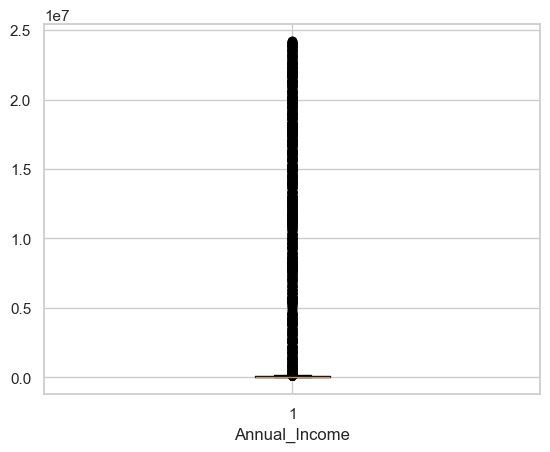

In [58]:
plt.boxplot(x='Annual_Income', data=credit_df)
plt.xlabel('Annual_Income')
plt.show()

In [59]:
income_check = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .nunique()
    .sort_values(ascending=False)
)

income_check[income_check > 1]

Customer_ID
CUS_0x58e3    4
CUS_0xc1fa    4
CUS_0x40e5    3
CUS_0x2748    3
CUS_0x473f    3
             ..
CUS_0xee1     2
CUS_0xf20     2
CUS_0xf55     2
CUS_0x1018    2
CUS_0xfa4     2
Name: Annual_Income, Length: 944, dtype: int64

In [60]:
income_check = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .unique()
)

income_check[income_check.apply(len) > 1]

Customer_ID
CUS_0x1018    [61194.81, 17117486.0]
CUS_0x1057     [86617.16, 1105753.0]
CUS_0x107e    [75095.91, 15741145.0]
CUS_0x108a    [36982.36, 11641815.0]
CUS_0x10a9    [17603.265, 9032145.0]
                       ...          
CUS_0xe5b     [43568.84, 17488375.0]
CUS_0xee1     [14630332.0, 17116.55]
CUS_0xf20     [58063.48, 20189519.0]
CUS_0xf55     [78443.48, 20350298.0]
CUS_0xfa4      [15035.19, 7711339.0]
Name: Annual_Income, Length: 944, dtype: object

In [61]:
credit_df['Annual_Income'] = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .transform(lambda x: x.mode().iloc[0])
)

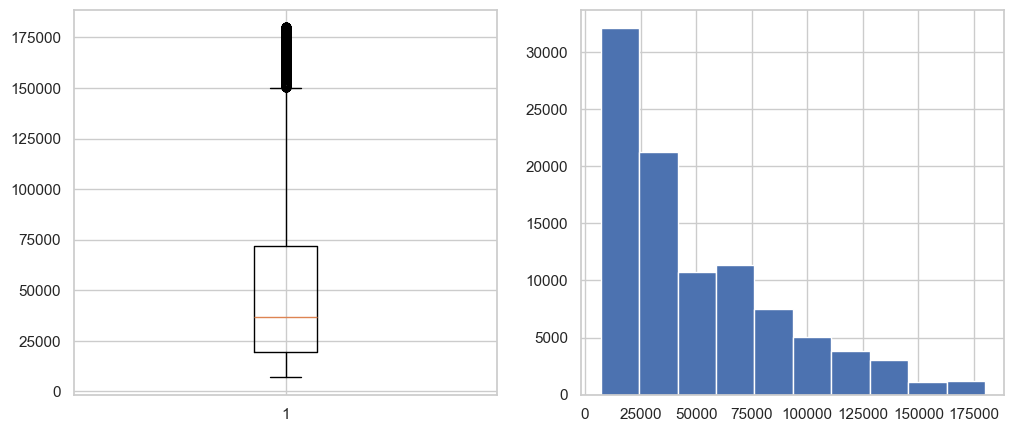

In [62]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.boxplot(x='Annual_Income', data=credit_df)
ax2.hist(x='Annual_Income', data=credit_df)
plt.show()

После заполнения графы ежегодный доход модой по каждому клиенту мы получили левое логнормальное распределение, характерное для зарплат. 

In [63]:
#посмотрим ежегодный и ежемесячный доход по профессиям
occupation_annual_income_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary']).round(2).sort_values(by='Annual_Income')

In [64]:
occupation_annual_income_df

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Journalist,48599.38,4026.48
Doctor,49467.54,4110.93
Lawyer,49502.06,4121.82
Teacher,49754.93,4124.63
Mechanic,50095.08,4139.25
Developer,50176.72,4159.15
Engineer,50649.58,4234.41
Media_Manager,50670.85,4214.80
Accountant,50711.25,4209.92


In [65]:
occupation_annual_income_median_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary'], aggfunc='median').round(2)

In [66]:
#посмотрим медиану
occupation_annual_income_median_df.sort_values(by='Annual_Income', ascending=False)

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Scientist,39487.82,3260.46
Engineer,39020.72,3201.51
Musician,38480.95,3130.68
Manager,38443.42,3245.01
Accountant,38391.66,3202.14
Architect,37827.77,3152.07
Writer,37769.92,3154.64
Entrepreneur,37482.37,3116.89
Media_Manager,36980.10,3138.63


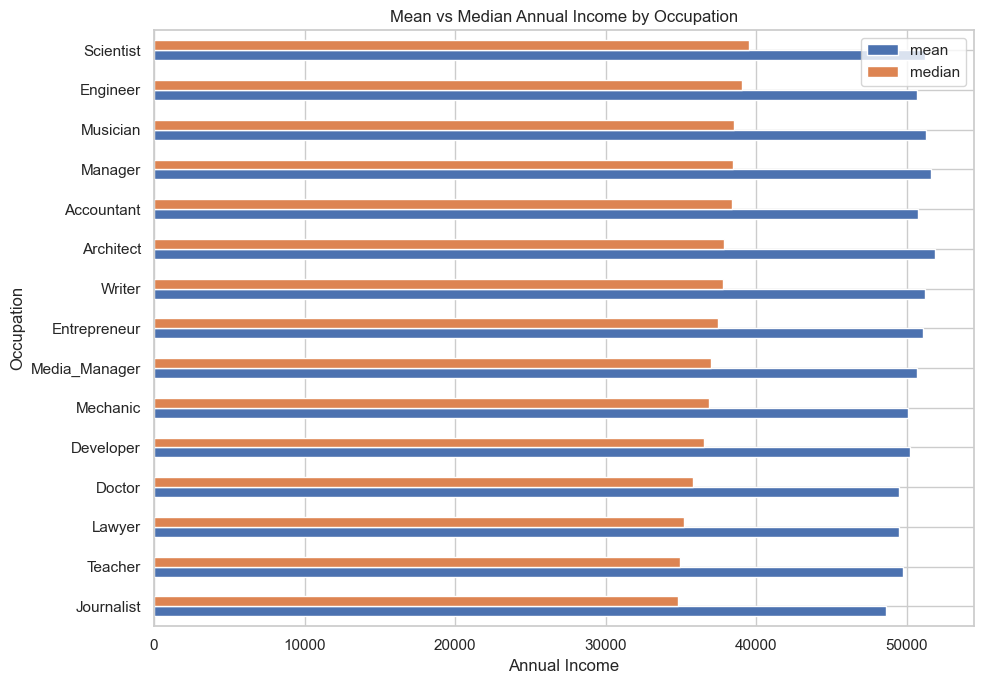

In [67]:
occupation_income = (
    credit_df.groupby('Occupation')['Annual_Income']
    .agg(['mean', 'median'])
    .sort_values('median')
)

ax = occupation_income.plot(
    kind='barh',
    figsize=(10, 7)
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Occupation')
ax.set_title('Mean vs Median Annual Income by Occupation')
plt.tight_layout()
plt.show()

Мы видим, что по всем профессия больше медианы. Более того, если сравнить медианы и средние, то порядок профессии меняется. Это говорит о том, что в некоторых профессия несколько высокооплачиваемых специалистов сдвигают среднее вправо. Главный вывод - среднее плохо годится, как описательная статистика для этого признака. Необходимо использовать медиану.

In [68]:
credit_df['Monthly_Inhand_Salary'] = (
    credit_df.groupby('Customer_ID')['Monthly_Inhand_Salary']
    .transform(
        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
)

**Выводы по анализу признака Annual_Income**
- Некорректные значения Annual_Income были восстановлены с использованием моды годового дохода для каждого клиента.
- По графикам распределения Annual_Income наблюдается правосторонняя асимметрия, характерная для распределений доходов: основная масса наблюдений сосредоточена в области относительно невысоких значений, при этом присутствует правый хвост высоких доходов.
При сравнении среднего и медианы обнаружено, что среднее значение стабильно превышает медиану для всех профессий. Это указывает на влияние высоких значений дохода на среднее.
- Особенно заметен разрыв между средним и медианным доходом в профессиях с относительно низким типичным уровнем дохода: наличие отдельных высокооплачиваемых клиентов смещает среднее значение вправо.
- В связи с этим медиана является более устойчивой и репрезентативной характеристикой типичного дохода клиента, чем среднее значение.

In [69]:
credit_df['Num_Bank_Accounts'].describe()

count    97227.000000
mean        17.127722
std        117.685312
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

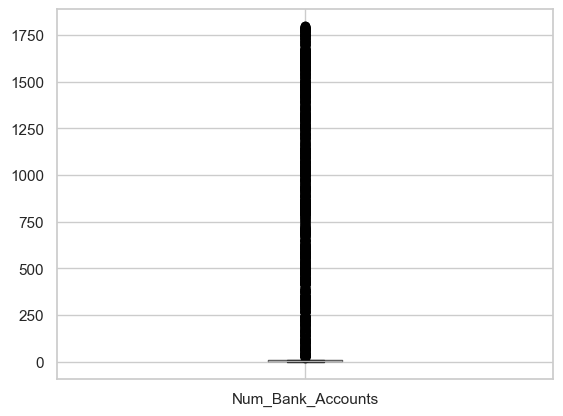

In [70]:
credit_df[['Num_Bank_Accounts']].boxplot()
plt.show()

Видим на графие большой хвост выбросов, а также то, что у нас есть отрицательное значение -1 и максимальное 1798. Проанализируем максимальные и минимальные значения. Посмотрим общее количество банковских аккаунтов.

In [71]:
credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1791,CUS_0x4004,April,Carlosj,44,679-26-6464,Writer,58317.00,4664.750000,1414,5,...,Standard,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard
0x17d0,CUS_0x42ac,July,Lawrencea,37,700-60-3660,Musician,15566.02,1423.168333,67,5,...,Standard,1693.95,29.706454,8 Years and 4 Months,Yes,43.070520,80.48442010154183,!@9#%8,308.76189362947565,Poor
0x17fd,CUS_0x9bc1,April,Jaisinghanij,42,445-18-4420,Architect,20574.47,1740.539167,572,3,...,Standard,749.95,36.559538,11 Years and 2 Months,Yes,49.348666,25.161404432750263,High_spent_Medium_value_payments,349.54384591241774,Standard
0x1816,CUS_0xaedb,May,Olivia Oranr,19,272-47-1135,Musician,85554.03,7185.502500,1488,2,...,_,1095.73,41.661802,19 Years and 11 Months,No,0.000000,70.82263261910934,High_spent_Large_value_payments,887.7276173808908,Good
0x1a6e,CUS_0x8643,May,Steve Slatery,33,198-08-9791,Musician,14205.09,1086.757500,91,10,...,Bad,4845.24,30.989504,NaN,Yes,49.032395,64.58804984795468,Low_spent_Large_value_payments,265.05530468293233,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25d89,CUS_0x544,August,Jon Herskovitzu,29,163-45-1172,Mechanic,17013.29,1326.774167,813,1,...,_,1452.79,28.051684,32 Years and 6 Months,NM,13.109663,55.72695329443804,Low_spent_Small_value_payments,353.840801,Good
0x25dd0,CUS_0x296f,July,David Millikenh,25,972-13-0672,Developer,125271.96,10374.330000,1481,7,...,Good,827.56,33.201730,25 Years and 8 Months,NM,241.065885,180.56001463373025,!@9#%8,855.8071,Poor
0x25dfc,CUS_0xb09,March,Lianau,31,228-47-4867,Lawyer,146310.68,12124.556667,474,4,...,Good,928.28,43.274889,22 Years and 3 Months,No,72.250125,121.28482498252883,High_spent_Large_value_payments,1258.920717,Standard


In [72]:
result = (
    credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]
    .groupby('Customer_ID')['Num_Bank_Accounts']
    .unique()
)

result[result.apply(len) > 1]

Customer_ID
CUS_0x112e        [1678, 1352]
CUS_0x138d          [230, 162]
CUS_0x14ce     [761, 569, 955]
CUS_0x16d5         [1153, 239]
CUS_0x19e1          [907, 205]
CUS_0x1b66          [211, 385]
CUS_0x1e2d          [201, 334]
CUS_0x1e3e         [1325, 290]
CUS_0x1eea          [550, 501]
CUS_0x1f2f        [1146, 1411]
CUS_0x22b9        [1751, 1503]
CUS_0x24d4         [857, 1714]
CUS_0x28e2    [295, 1668, 354]
CUS_0x2999         [936, 1620]
CUS_0x29b1        [1506, 1472]
CUS_0x3359        [1041, 1404]
CUS_0x3b37         [1549, 848]
CUS_0x3d99         [1617, 566]
CUS_0x4190          [921, 364]
CUS_0x48aa        [1312, 1315]
CUS_0x4dd5         [445, 1168]
CUS_0x5499         [527, 1350]
CUS_0x59f1          [1236, 59]
CUS_0x5b57          [264, 194]
CUS_0x61b7          [322, 628]
CUS_0x6273          [734, 511]
CUS_0x6397         [112, 1561]
CUS_0x746c          [1078, 64]
CUS_0x7aae          [324, 406]
CUS_0x7dfb          [741, 121]
CUS_0x7f0a          [179, 844]
CUS_0x836e         [1583, 3

Эти банковские аккаунты невозможно восстановить из имеющихся данных: в них только невалидные значения для данной графы. Их мало и их удалю.

In [73]:
problem_customers = result[result.apply(len) > 1].index

credit_df = credit_df[
    ~credit_df['Customer_ID'].isin(problem_customers)
]
credit_df = credit_df.copy()

In [74]:
credit_df.loc[credit_df['Num_Bank_Accounts'] < 0]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
0xc7b9,CUS_0x4f2a,April,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good
0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,37.286105,20 Years and 6 Months,No,0.000000,668.1444536762707,!@9#%8,588.9477963237292,Poor
0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.915627,20 Years and 7 Months,No,0.000000,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.799942,20 Years and 8 Months,No,0.000000,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor


In [75]:
credit_df[credit_df['Num_Bank_Accounts'] == 1798]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x8ccf,CUS_0x7fd9,June,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,1798,7,...,Good,1330.02,21.743562,18 Years and 0 Months,No,46.244585,264.3665957522356,Low_spent_Large_value_payments,245.94065263077442,Standard
0x19027,CUS_0x11c1,February,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,1798,3,...,Standard,533.71,34.380248,19 Years and 9 Months,Yes,66.210327,282.83977688221506,Low_spent_Small_value_payments,164.03506268873434,Standard


In [76]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x7fd9']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x8cca,CUS_0x7fd9,January,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,33.741883,17 Years and 7 Months,No,46.244585,41.0222288776369,High_spent_Large_value_payments,439.28501950537293,Standard
0x8ccb,CUS_0x7fd9,February,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,37.601963,17 Years and 8 Months,NM,46.244585,34.13407212736563,High_spent_Large_value_payments,446.17317625564436,Standard
0x8ccc,CUS_0x7fd9,March,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,_,1330.02,23.481559,17 Years and 9 Months,NM,46.244585,368.7055196194469,Low_spent_Small_value_payments,161.6017287635631,Standard
0x8cce,CUS_0x7fd9,May,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,33.743120,17 Years and 11 Months,No,46.244585,110.35298021862238,High_spent_Medium_value_payments,379.9542681643876,Standard
0x8ccf,CUS_0x7fd9,June,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,1798,7,...,Good,1330.02,21.743562,18 Years and 0 Months,No,46.244585,264.3665957522356,Low_spent_Large_value_payments,245.94065263077442,Standard
0x8cd0,CUS_0x7fd9,July,en Deightono,56,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,_,1330.02,25.276571,18 Years and 1 Months,No,46.244585,168.49692256371287,Low_spent_Large_value_payments,341.81032581929713,Standard
0x8cd1,CUS_0x7fd9,August,en Deightono,56,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,35.871065,18 Years and 2 Months,NM,46.244585,226.873707316444,Low_spent_Small_value_payments,303.433541066566,Standard


In [77]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x11c1']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x19026,CUS_0x11c1,January,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,28.449959,19 Years and 8 Months,Yes,66.210327,173.75926050258002,Low_spent_Small_value_payments,273.11557906836936,Standard
0x19027,CUS_0x11c1,February,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,1798,3,...,Standard,533.71,34.380248,19 Years and 9 Months,Yes,66.210327,282.83977688221506,Low_spent_Small_value_payments,164.03506268873434,Standard
0x19028,CUS_0x11c1,March,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,38.700394,19 Years and 10 Months,Yes,66.210327,141.6147987112849,!@9#%8,275.2600408596645,Standard
0x19029,CUS_0x11c1,April,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,31.355523,19 Years and 11 Months,Yes,66.210327,47.77036669728128,High_spent_Medium_value_payments,359.10447287366816,Standard
0x1902a,CUS_0x11c1,May,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,31.277406,20 Years and 0 Months,Yes,66.210327,115.02505043046536,Low_spent_Medium_value_payments,321.84978914048406,Standard
0x1902b,CUS_0x11c1,June,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,32.290532,20 Years and 1 Months,Yes,66.210327,204.57678263227075,Low_spent_Large_value_payments,222.2980569386787,Standard
0x1902c,CUS_0x11c1,July,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,25.404598,20 Years and 2 Months,NM,66.210327,205.67758345658862,!@9#%8,241.1972561143608,Standard
0x1902d,CUS_0x11c1,August,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,38.321831,NaN,Yes,66.210327,44.11332027545772,!@9#%8,352.7615192954917,Standard


In [78]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x4f2a']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0xc7b6,CUS_0x4f2a,January,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,...,Good,1151.7,28.555646,22 Years and 3 Months,No,196.587321,268.7720817598091,High_spent_Medium_value_payments,828.0552637408804,Standard
0xc7b7,CUS_0x4f2a,February,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,...,Good,1151.7,30.343064,22 Years and 4 Months,No,196.587321,588.7732847049177,Low_spent_Small_value_payments,548.0540607957716,Standard
0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
0xc7b9,CUS_0x4f2a,April,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good


Здесь мы видим вероятную причину возникновения -1 в количестве банковских счетов. Если в системе указано нулевое количество банковских счетов, а количество кредитных карт уменьшается на единицу, то вычетание из 0 единицы дает -1. Проверим эту теорию.

In [79]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xa878']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x115fe,CUS_0xa878,January,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,0,7,...,_,607.78,31.531889,20 Years and 5 Months,No,0.0,394.2919200897653,High_spent_Medium_value_payments,842.8003299102347,Poor
0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,37.286105,20 Years and 6 Months,No,0.0,668.1444536762707,!@9#%8,588.9477963237292,Poor
0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,41.915627,20 Years and 7 Months,No,0.0,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,41.799942,20 Years and 8 Months,No,0.0,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor
0x11602,CUS_0xa878,May,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,46.244581,20 Years and 9 Months,No,0.0,NaN,High_spent_Large_value_payments,1037.5063384360787,Poor
0x11603,CUS_0xa878,June,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,32.303737,20 Years and 10 Months,No,0.0,218.00522319835895,High_spent_Medium_value_payments,1019.0870268016413,Poor
0x11604,CUS_0xa878,July,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,30.709169,20 Years and 11 Months,No,0.0,352.80115804899873,High_spent_Medium_value_payments,884.2910919510015,Poor
0x11605,CUS_0xa878,August,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,34.041733,21 Years and 0 Months,No,0.0,467.41582464616476,High_spent_Small_value_payments,779.6764253538355,Poor


In [80]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x5993']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x15bfb,CUS_0x5993,February,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,0,5,...,Good,644.57,30.230648,NaN,No,16.483566,143.32297249655755,High_spent_Small_value_payments,331.9277112802258,Standard
0x15bfc,CUS_0x5993,March,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,0,5,...,_,644.57,38.822428,23 Years and 7 Months,No,16.483566,60.681955753649085,High_spent_Small_value_payments,414.5687280231343,Standard
0x15bfd,CUS_0x5993,April,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,0,5,...,Good,644.57,36.351893,23 Years and 8 Months,NM,16.483566,54.56979945313372,High_spent_Large_value_payments,400.6808843236496,Standard
0x15bfe,CUS_0x5993,May,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,-1,165,...,Good,644.57,25.532001,23 Years and 9 Months,NM,16.483566,126.66534532381421,Low_spent_Medium_value_payments,368.5853384529692,Standard
0x15bff,CUS_0x5993,June,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,31.813259,23 Years and 10 Months,No,16.483566,54.82132668337657,High_spent_Large_value_payments,400.42935709340685,Standard
0x15c00,CUS_0x5993,July,Stephensonq,41,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,26.574175,23 Years and 11 Months,No,16.483566,64.86083753440263,!@9#%8,400.38984624238066,Standard
0x15c01,CUS_0x5993,August,Stephensonq,41,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,32.937399,24 Years and 0 Months,No,16.483566,89.62296249058659,High_spent_Medium_value_payments,375.62772128619685,Standard


Да, причина выявлена. Можно дать рекомендацию разработчикам баз данных проверить код, связанный с этой ошибкой. Значение -1 можно заменить на значение ноль по всему датафрейму.

In [81]:
credit_df['Num_Bank_Accounts'] = credit_df['Num_Bank_Accounts'].replace(-1, 0)

Теперь оценим максимальное количество банковских счетов. Посмотрим, есть ли у клиентов, кроме запредельного количества счетов, и валидные значения. Если большое количество единично, то считаем его ошибкой и заменяем валидным значением для клиента из его других граф.

In [82]:
credit_df['Num_Bank_Accounts'].describe()

count    96805.000000
mean        16.210857
std        113.146832
min          0.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [83]:
result = (
    credit_df.groupby('Customer_ID')['Num_Bank_Accounts']
    .agg(['nunique', 'max'])
)

result = result[
    (result['nunique'] >= 2) &
    (result['max'] > 20)
]
result

,nunique,max
Customer_ID,,
CUS_0x102d,2,1000
CUS_0x104a,2,124
CUS_0x109d,2,232
CUS_0x109f,2,561
CUS_0x10a9,2,1725
...,...,...
CUS_0xf01,2,782
CUS_0xf19,2,1763
CUS_0xf2e,2,1634


In [84]:
result = (
    credit_df.groupby('Customer_ID')['Num_Bank_Accounts']
    .unique()
)

result = result[
    result.apply(lambda x: len(x) >= 2 and any(v > 20 for v in x))
]
result

Customer_ID
CUS_0x102d      [5, 1000]
CUS_0x104a       [2, 124]
CUS_0x109d      [10, 232]
CUS_0x109f       [4, 561]
CUS_0x10a9      [8, 1725]
                 ...     
CUS_0xf01        [0, 782]
CUS_0xf19       [5, 1763]
CUS_0xf2e      [10, 1634]
CUS_0xf43       [8, 1644]
CUS_0xfac     [5, 6, 796]
Name: Num_Bank_Accounts, Length: 1170, dtype: object

In [85]:
valid_values = (
    credit_df[credit_df['Num_Bank_Accounts'] < 21]
    .groupby('Customer_ID')['Num_Bank_Accounts']
    .first()
)

In [86]:
mask = (
    credit_df['Customer_ID'].isin(result.index) &
    (credit_df['Num_Bank_Accounts'] >= 21)
)

credit_df.loc[mask, 'Num_Bank_Accounts'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_values)
)

In [87]:
credit_df['Num_Bank_Accounts'].describe()

count    96805.000000
mean         5.368969
std          2.592616
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         18.000000
Name: Num_Bank_Accounts, dtype: float64

**Выводы по признаку Num_Bank_Accounts**
- Выявлены клиенты с аномально высоким количеством банковских аккаунтов; такие наблюдения были исключены из дальнейшего анализа.
- Для клиентов, у которых встречалось единичное аномально высокое значение, проведена проверка остальных записей клиента.
- Если у клиента было доступно валидное значение Num_Bank_Accounts, аномальное значение было заменено на него.
- Клиенты, для которых не удалось определить корректное значение, были исключены из датасета.
- Значение -1 вызывано некорректной обработкой связи количества кредитных карт и количества банковских аккаунтов. При уменьшении кредитных карт на единицу и нулевом значении банковских аккаунтов, количество банковских аккаунтов менялось на -1.
- значение -1 было заменено на 0 по всему датафрейму

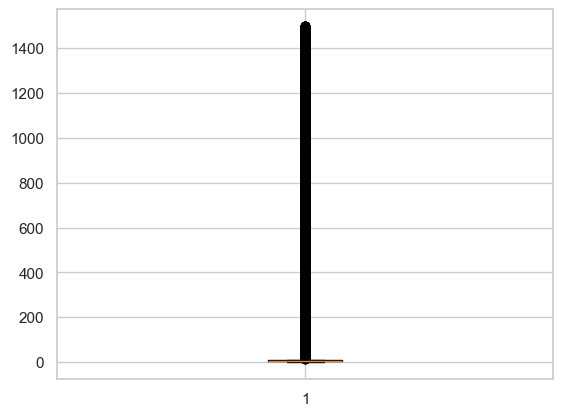

In [88]:
plt.boxplot(credit_df[['Num_Credit_Card']])
plt.show()

In [89]:
credit_df['Num_Credit_Card'].describe()

count    96805.000000
mean        22.464170
std        128.921551
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max       1499.000000
Name: Num_Credit_Card, dtype: float64

- Отрицательных значений нет.
- Есть выбросы

In [90]:
credit_df['Num_Credit_Card'].loc[credit_df['Num_Credit_Card'] >= 20].count() 

np.int64(2196)

In [91]:
result = (
    credit_df.loc[credit_df['Num_Credit_Card'] > 20]
    .groupby('Customer_ID')['Num_Credit_Card']
    .unique()
)

result[result.apply(len) > 1]

Customer_ID
CUS_0x1130     [855, 726]
CUS_0x1325    [1439, 547]
CUS_0x1458     [756, 573]
CUS_0x178b     [659, 680]
CUS_0x181a     [552, 104]
                 ...     
CUS_0xc5ae    [130, 1101]
CUS_0xc5ea    [605, 1077]
CUS_0xc675    [1030, 870]
CUS_0xcfc      [745, 106]
CUS_0xff3     [1168, 363]
Name: Num_Credit_Card, Length: 141, dtype: object

In [92]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x1130']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x2582a,CUS_0x1130,January,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,5,...,_,1056.3,32.235055,26 Years and 11 Months,No,0.000000,137.37331589978876,!@9#%8,1272.450684,Standard
0x2582b,CUS_0x1130,February,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,5,...,Standard,1056.3,34.440104,27 Years and 0 Months,No,0.000000,954.8202497287346,Low_spent_Small_value_payments,495.00375,Standard
0x2582c,CUS_0x1130,March,Elizabethr,37,846-60-3664,Journalist,137798.88,11598.240000,6,5,...,Standard,1056.3,46.145169,27 Years and 1 Months,No,0.000000,171.21428039656428,High_spent_Large_value_payments,1228.60972,Standard
0x2582d,CUS_0x1130,April,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,5,...,Standard,1056.3,39.442444,27 Years and 2 Months,No,988.448091,100.22424748516632,High_spent_Large_value_payments,1299.599753,Good
0x2582e,CUS_0x1130,May,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,5,...,Standard,1056.3,36.832755,27 Years and 3 Months,No,988.448091,163.0540354399817,High_spent_Large_value_payments,1236.769965,Good
0x2582f,CUS_0x1130,June,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,5,...,Standard,1056.3,34.523299,27 Years and 4 Months,No,988.448091,NaN,Low_spent_Medium_value_payments,416.203392,Good
0x25830,CUS_0x1130,July,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,855,...,Standard,1056.3,39.990533,27 Years and 5 Months,No,988.448091,__10000__,High_spent_Large_value_payments,1307.770293,Good
0x25831,CUS_0x1130,August,Elizabethr,37,846-60-3664,Journalist,137798.88,10609.791909,6,726,...,Standard,1056.3,30.054311,NaN,No,988.448091,1156.953782699478,Low_spent_Medium_value_payments,282.870217,Good


In [93]:
Num_credit_card_df = credit_df[credit_df['Customer_ID'].isin(result.index)][['Num_Credit_Card', 'Customer_ID']]
Num_credit_card_df.reset_index(drop=True)

,Num_Credit_Card,Customer_ID
0,4,CUS_0x21b1
1,4,CUS_0x21b1
2,1385,CUS_0x21b1
3,4,CUS_0x21b1
4,4,CUS_0x21b1
...,...,...
16021,158,CUS_0x64f0
16022,7,CUS_0x64f0
16023,7,CUS_0x64f0
16024,7,CUS_0x64f0


In [94]:
# Находим для каждого Customer_ID значение Num_Credit_Card < 20
valid_values = (
    credit_df[credit_df['Num_Credit_Card'] < 20]
    .groupby('Customer_ID')['Num_Credit_Card']
    .first()
)

# Заменяем значения >= 20 на найденное корректное значение клиента
credit_df['Num_Credit_Card'] = (
    credit_df['Customer_ID']
    .map(valid_values)
    .fillna(credit_df['Num_Credit_Card'])
)

In [95]:
credit_df['Num_Credit_Card'].describe()

count    96805.000000
mean         5.534662
std          2.067807
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         17.000000
Name: Num_Credit_Card, dtype: float64

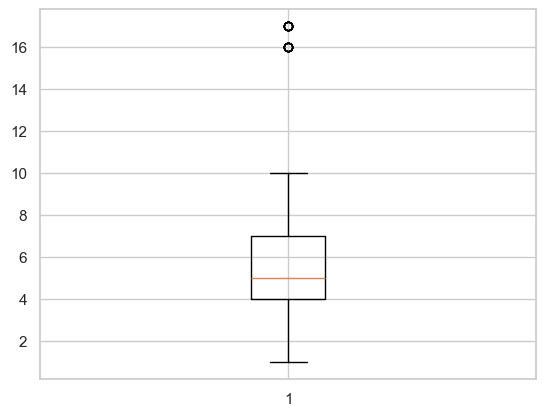

In [96]:
plt.boxplot(credit_df['Num_Credit_Card'])
plt.show()

**выводы по признаку Num_credit_card**
- в ходе анализа выявлены аномальные значения признака Num_Credit_Card.
- установлено, что аномалии обусловлены ошибками в исходных данных.
- аномальные значения были скорректированы путём замены на валидные значения, соответствующие конкретному клиенту.

In [97]:
credit_df['Interest_Rate'].describe()

count    96805.000000
mean        72.588596
std        467.131269
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max       5797.000000
Name: Interest_Rate, dtype: float64

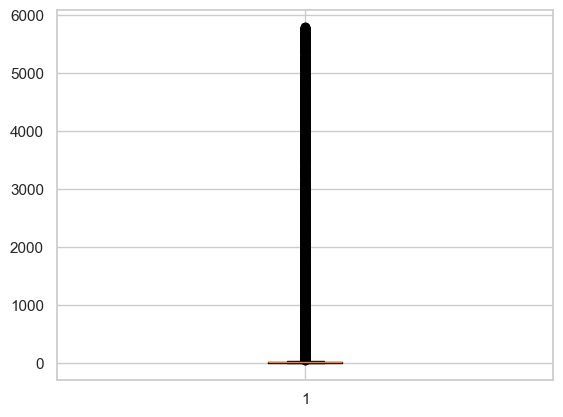

In [98]:
plt.boxplot(credit_df['Interest_Rate'])
plt.show()

In [99]:
credit_df[credit_df['Interest_Rate'] > 40][['Customer_ID', 'Interest_Rate']]

,Customer_ID,Interest_Rate
ID,,
0x1642,CUS_0x95ee,5318
0x1687,CUS_0xc0ab,433
0x16f9,CUS_0x132f,5240
0x170c,CUS_0xac86,4975
0x1757,CUS_0xbffe,668
...,...,...
0x25eb5,CUS_0x62f5,4396
0x25ec7,CUS_0x1232,387
0x25f40,CUS_0x47fa,1947


In [100]:
valid_values = (
    credit_df[credit_df['Interest_Rate'] < 40]
    .groupby('Customer_ID')['Interest_Rate']
    .first()
)

# Заменяем значения >= 40 на найденное корректное значение клиента
credit_df['Interest_Rate'] = (
    credit_df['Customer_ID']
    .map(valid_values)
    .fillna(credit_df['Interest_Rate'])
)

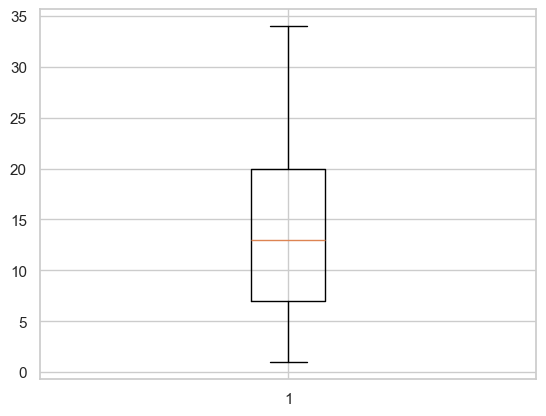

In [101]:
plt.boxplot(credit_df['Interest_Rate'])
plt.show()

**выводы по признаку Interest Rate**

- в ходе анализа выявлены аномальные значения признака Interest Rate.
- установлено, что аномалии обусловлены ошибками в исходных данных.
- аномальные значения были скорректированы путём замены на валидные значения, соответствующие конкретному клиенту.

In [102]:
credit_df['Num_of_Loan'].describe()

count     96805
unique      417
top           3
freq      13936
Name: Num_of_Loan, dtype: object

In [103]:
credit_df['Num_of_Loan'].unique()

array(['4', '1', '3', '967', '-100', '0', '0_', '2', '3_', '2_', '7', '5',
       '5_', '6', '8', '8_', '9', '9_', '4_', '7_', '1_', '1464', '6_',
       '622', '352', '1017', '945', '146', '563', '341', '720', '1485',
       '49', '737', '1106', '466', '728', '313', '597_', '119', '663',
       '640', '92_', '1019', '501', '1302', '39', '716', '848', '931',
       '1214', '186', '424', '1001', '1110', '1152', '457', '1433',
       '1187', '52', '1480', '1047', '1035', '1347_', '33', '193', '699',
       '329', '1451', '484', '649', '995', '545', '684', '1135', '1094',
       '1204', '654', '58', '348', '614', '1363', '323', '1406', '1348',
       '430', '153', '1461', '905', '1312', '1424', '1154', '95', '1353',
       '1228', '819', '1006', '795', '359', '1209', '590', '696', '1185_',
       '1465', '911', '70', '816', '1369', '143', '1416', '455', '55',
       '1096', '1474', '420', '904', '89', '1259', '527', '1241', '449',
       '983', '418', '319', '23', '238', '638', '138', '23

In [104]:
credit_df['Num_of_Loan'] = credit_df['Num_of_Loan'].str.replace('_', '')
credit_df['Num_of_Loan'] = credit_df['Num_of_Loan'].astype('int32')

In [105]:
credit_df['Num_of_Loan'].unique()

array([   4,    1,    3,  967, -100,    0,    2,    7,    5,    6,    8,
          9, 1464,  622,  352, 1017,  945,  146,  563,  341,  720, 1485,
         49,  737, 1106,  466,  728,  313,  597,  119,  663,  640,   92,
       1019,  501, 1302,   39,  716,  848,  931, 1214,  186,  424, 1001,
       1110, 1152,  457, 1433, 1187,   52, 1480, 1047, 1035, 1347,   33,
        193,  699,  329, 1451,  484,  649,  995,  545,  684, 1135, 1094,
       1204,  654,   58,  348,  614, 1363,  323, 1406, 1348,  430,  153,
       1461,  905, 1312, 1424, 1154,   95, 1353, 1228,  819, 1006,  795,
        359, 1209,  590,  696, 1185, 1465,  911,   70,  816, 1369,  143,
       1416,  455,   55, 1096, 1474,  420,  904,   89, 1259,  527, 1241,
        449,  983,  418,  319,   23,  238,  638,  138,  235,  280, 1070,
       1484,  274,  494, 1459,  404, 1354, 1495, 1391,  601, 1313, 1319,
        898,  231,  752,  174,  961, 1046,  834,  284,  438,  288, 1463,
       1151,  719,  198, 1015,  855,  841,  392, 14

In [106]:
credit_df['Num_of_Loan'].describe()

count    96805.000000
mean         2.964248
std         62.291315
min       -100.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1496.000000
Name: Num_of_Loan, dtype: float64

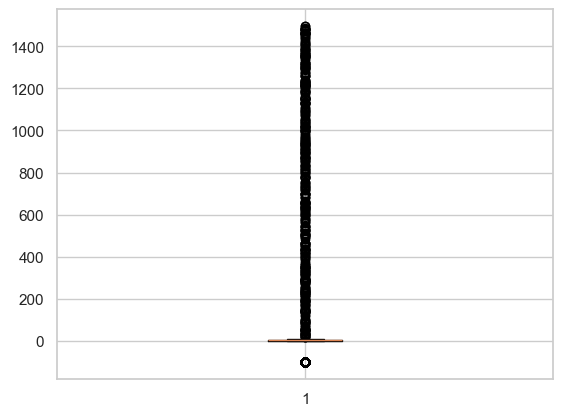

In [107]:
plt.boxplot(credit_df['Num_of_Loan'])
plt.show()

In [108]:
# Находим для каждого Customer_ID значение Num_Credit_Card < 20
valid_values = (
    credit_df[(credit_df['Num_of_Loan'] < 10) & (credit_df['Num_of_Loan'] >= 0)]
    .groupby('Customer_ID')['Num_of_Loan']
    .first()
)

# Заменяем значения >= 20 на найденное корректное значение клиента
credit_df['Num_of_Loan'] = (
    credit_df['Customer_ID']
    .map(valid_values)
    .fillna(credit_df['Num_of_Loan'])
)

In [109]:
credit_df['Num_of_Loan'].describe()

count    96805.000000
mean         3.533247
std          2.445814
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max          9.000000
Name: Num_of_Loan, dtype: float64

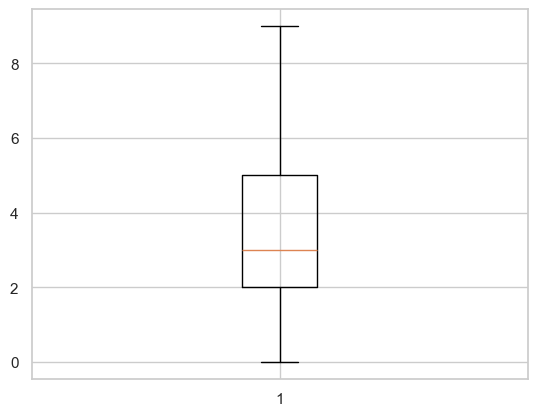

In [110]:
plt.boxplot(credit_df['Num_of_Loan'])
plt.show()

**выводы по признаку Num_of_Loan**
- исправлены ошибки кодировки
- измненен тип данных с object на int32
- в ходе анализа выявлены аномальные значения признака
- установлено, что аномалии обусловлены ошибками в исходных данных.
- аномальные значения были скорректированы путём замены на валидные значения, соответствующие конкретному клиенту.

In [111]:
credit_df['Type_of_Loan'].describe()

count             85791
unique             6234
top       Not Specified
freq               1368
Name: Type_of_Loan, dtype: object

In [112]:
credit_df['Type_of_Loan'].unique()

array(['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
       'Credit-Builder Loan', 'Auto Loan, Auto Loan, and Not Specified',
       ..., 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan',
       'Payday Loan, Student Loan, Mortgage Loan, and Not Specified',
       'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan'],
      dtype=object)

In [113]:
credit_df['Type_of_Loan'] = (
    credit_df['Type_of_Loan']
    .fillna('Not Specified')
    .str.replace(' and ', ', ', regex=False)
    .str.split(',')
    .apply(lambda x: [i.strip() for i in x if i.strip()])
)

In [114]:
all_loans = []

for index, row in credit_df.iterrows():
    loans = row['Type_of_Loan']
    
    for loan in loans:
        all_loans.append(loan.strip())

In [115]:
loan_counts = Counter(all_loans)
print(loan_counts.keys())

dict_keys(['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan', 'Not Specified', 'Mortgage Loan', 'Student Loan', 'Debt Consolidation Loan', 'Payday Loan'])


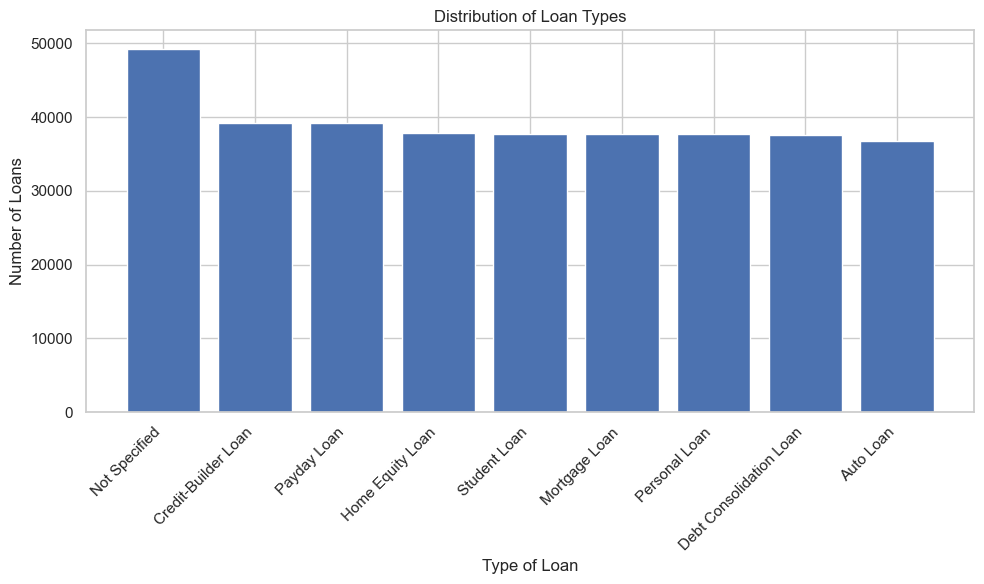

In [116]:
loan_counts_sorted = dict(
    sorted(loan_counts.items(), key=lambda x: x[1], reverse=True)
)

plt.figure(figsize=(10, 6))
plt.bar(loan_counts_sorted.keys(), loan_counts_sorted.values())

plt.xticks(rotation=45, ha='right')
plt.xlabel('Type of Loan')
plt.ylabel('Number of Loans')
plt.title('Distribution of Loan Types')

plt.tight_layout()
plt.show()

**Выводы по признаку type of Loan**
- пропуски по типу кредита заполнены как Not Specified
- проанализированы основные типы кредитов
- выделены 9 основных категорий, которые можно использовать для построения модели
- самая популярная категория кредита: кредит на постройку (покупку здания)
- самая маленькая категория кредита: кредит на машину
- категории типов кредита по количеству клиентов различаются незначительно

In [117]:
credit_df['Delay_from_due_date'].describe()

count    96805.000000
mean        21.068788
std         14.858024
min         -5.000000
25%         10.000000
50%         18.000000
75%         28.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64

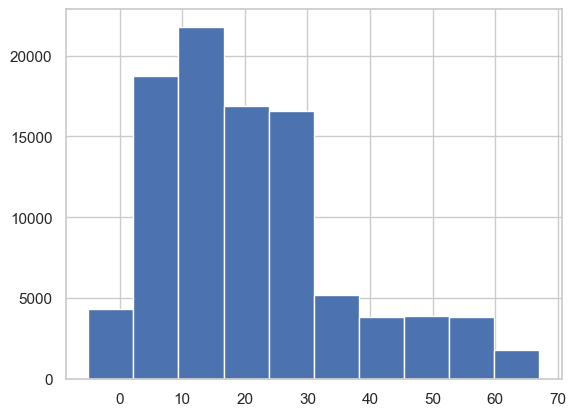

In [118]:
plt.hist(credit_df['Delay_from_due_date'])
plt.show()

**Выводы по признаку Delay from due date**
- Значения признака выглядят корректными
- Отрицательные значения обусловлены оплатой кредита раньше срока
- Максимальная просрочка по кредиту более двух месяцев (68 дней)
- Большинство клиентов допускают просрочки до 20 дней
- Выявленные пропущенные значения для последующего анализа рекомендуется заполнять медианой или удалить

In [119]:
credit_df['Num_of_Delayed_Payment'].unique()

array(['7', nan, '4', '8_', '6', '1', '-1', '3_', '0', '8', '5', '3', '9',
       '12', '15', '17', '10', '2', '2_', '14', '11', '20', '22', '13',
       '13_', '14_', '16', '12_', '18', '19', '23', '24', '21', '3318',
       '3083', '22_', '1338', '26', '11_', '3104', '21_', '25', '10_',
       '183_', '1106', '834', '19_', '24_', '17_', '23_', '2672', '20_',
       '4_', '2008', '-3', '538', '6_', '1_', '16_', '27', '3478', '2420',
       '15_', '707', '708', '26_', '18_', '3815', '9_', '28', '5_', '-2',
       '1867', '2250', '1463', '25_', '7_', '2882', '1941', '2655',
       '2628', '132', '3069', '306', '0_', '3539', '3684', '1823', '4128',
       '1946', '827', '2297', '2566', '904', '182', '929', '3568', '2503',
       '1552', '2812', '1697', '3764', '851', '3905', '923', '88', '1668',
       '3253', '808', '2689', '3858', '642', '3457', '1402', '1732',
       '3154', '847', '3037', '2204', '3103', '1063', '2056', '1282',
       '1841', '2569_', '211', '793', '3484', '411', '34

In [120]:
credit_df['Num_of_Delayed_Payment'] = credit_df['Num_of_Delayed_Payment'].str.replace('_', '', regex=False).replace('nan', np.nan).astype('float')

In [121]:
credit_df['Num_of_Delayed_Payment'].describe()

count    90012.000000
mean        30.955373
std        225.985385
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4397.000000
Name: Num_of_Delayed_Payment, dtype: float64

In [122]:
valid_values = (
    credit_df[
        credit_df['Num_of_Delayed_Payment'].between(0, 40)
    ]
    .groupby('Customer_ID')['Num_of_Delayed_Payment']
    .first()
)

credit_df['Num_of_Delayed_Payment'] = (
    credit_df['Customer_ID']
    .map(valid_values)
    .fillna(credit_df['Num_of_Delayed_Payment'])
)

In [123]:
credit_df['Num_of_Delayed_Payment'].describe()

count    96805.000000
mean        13.322442
std          6.289365
min          0.000000
25%          9.000000
50%         14.000000
75%         18.000000
max         28.000000
Name: Num_of_Delayed_Payment, dtype: float64

In [124]:
credit_df.loc[
    credit_df['Num_of_Delayed_Payment'] < 0,
    'Num_of_Delayed_Payment'
] = np.nan

In [125]:
credit_df['Num_of_Delayed_Payment'].describe()

count    96805.000000
mean        13.322442
std          6.289365
min          0.000000
25%          9.000000
50%         14.000000
75%         18.000000
max         28.000000
Name: Num_of_Delayed_Payment, dtype: float64

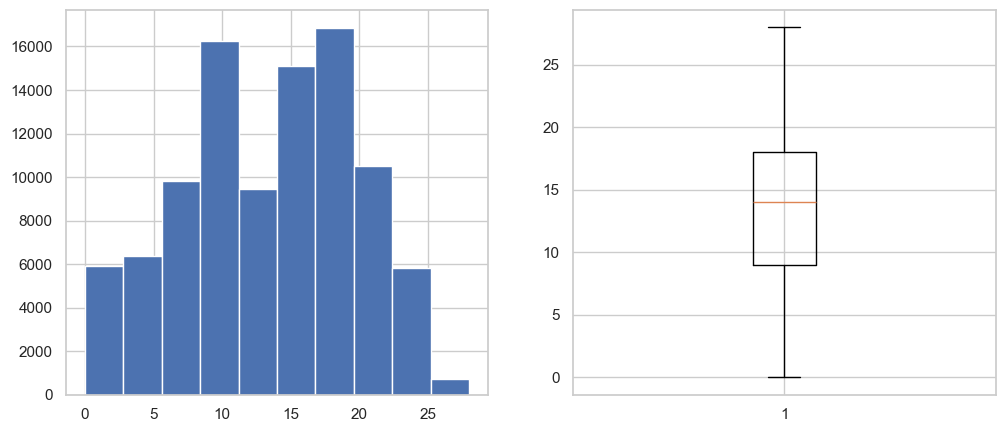

In [126]:
data = credit_df['Num_of_Delayed_Payment'].dropna()

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(data)
ax2.boxplot(data)
plt.show()

**Выводы по признаку Num_of_Delayed_Payment**
- Исправлены некорректные значения больше ста
- Отрицательные значения заменены на np.nan
- Медиана близка к среднему (mean=13.33, meadian=14)
- В иплиментации пропусков можно использовать, как среднюю, так и медиану
- Близость медианы и среднего указывают на отсутствие явно ассиметрии

In [127]:
credit_df['Changed_Credit_Limit'].describe()

count     96805
unique     4374
top           _
freq       2033
Name: Changed_Credit_Limit, dtype: object

In [128]:
credit_df['Changed_Credit_Limit'] = credit_df['Changed_Credit_Limit'].str.replace('_', '', regex=False).replace('nan', np.nan)
credit_df['Changed_Credit_Limit'] = pd.to_numeric(credit_df['Changed_Credit_Limit'],errors='coerce')

In [129]:
valid_values = (
    credit_df[credit_df['Changed_Credit_Limit'] > 0]
    .groupby('Customer_ID')['Changed_Credit_Limit']
    .first()
)


negative_mask = credit_df['Changed_Credit_Limit'] < 0

replacement_values = (
    credit_df.loc[negative_mask, 'Customer_ID']
    .map(valid_values)
)

credit_df.loc[negative_mask, 'Changed_Credit_Limit'] = replacement_values


In [130]:
credit_df['Changed_Credit_Limit'].describe()

count    94772.000000
mean        10.483038
std          6.658210
min          0.000000
25%          5.380000
50%          9.410000
75%         14.860000
max         36.970000
Name: Changed_Credit_Limit, dtype: float64

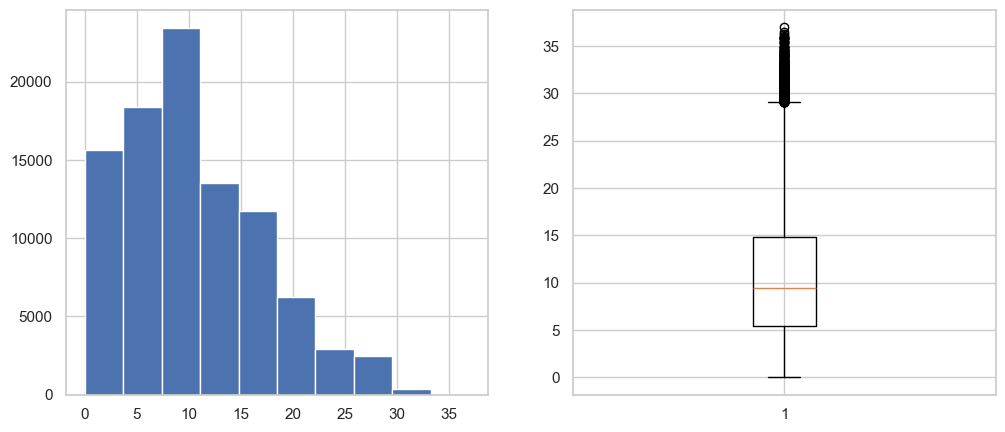

In [131]:
data = credit_df['Changed_Credit_Limit'].dropna()

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(data)
ax2.boxplot(data)
plt.show()

In [132]:
credit_df['Changed_Credit_Limit'] = (
    credit_df['Changed_Credit_Limit']
    .fillna(
        credit_df.groupby('Customer_ID')['Changed_Credit_Limit']
        .transform('median')
    )
)

In [133]:
credit_df['Changed_Credit_Limit'].describe()

count    96805.000000
mean        10.481873
std          6.654464
min          0.000000
25%          5.390000
50%          9.410000
75%         14.840000
max         36.970000
Name: Changed_Credit_Limit, dtype: float64

**Выводы по признаку Changed_Credit_Limit**
- признак очищен от некореектны значений
- пропуски и исправления значений произведены в соответствии c внутренним согласованием данных клиентов
- распределение имеет левый ассиметричный характер - большая часть клиентов просила именить кредитный лимит менее 10 раз

In [134]:
credit_df['Num_Credit_Inquiries'].describe()

count    94913.000000
mean        27.909022
std        193.807109
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max       2597.000000
Name: Num_Credit_Inquiries, dtype: float64

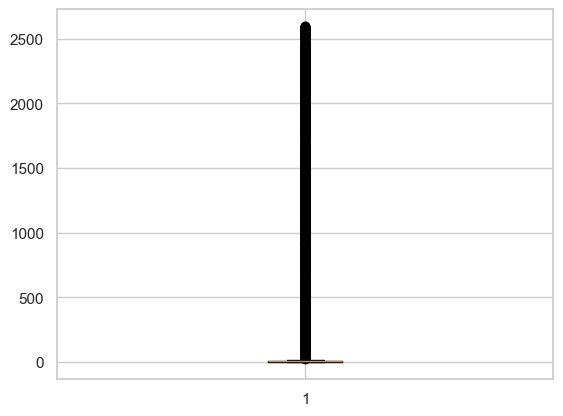

In [135]:
plt.boxplot(credit_df['Num_Credit_Inquiries'].dropna())
plt.show()

In [136]:
valid_values = (
    credit_df[credit_df['Num_Credit_Inquiries'] < 100]
    .groupby('Customer_ID')['Num_Credit_Inquiries']
    .first()
)

credit_df['Num_Credit_Inquiries'] = (
    credit_df['Customer_ID']
    .map(valid_values)
    .fillna(credit_df['Num_Credit_Inquiries'])
)

In [137]:
credit_df['Num_Credit_Inquiries'].describe()

count    96805.000000
mean         4.959672
std          3.720883
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         74.000000
Name: Num_Credit_Inquiries, dtype: float64

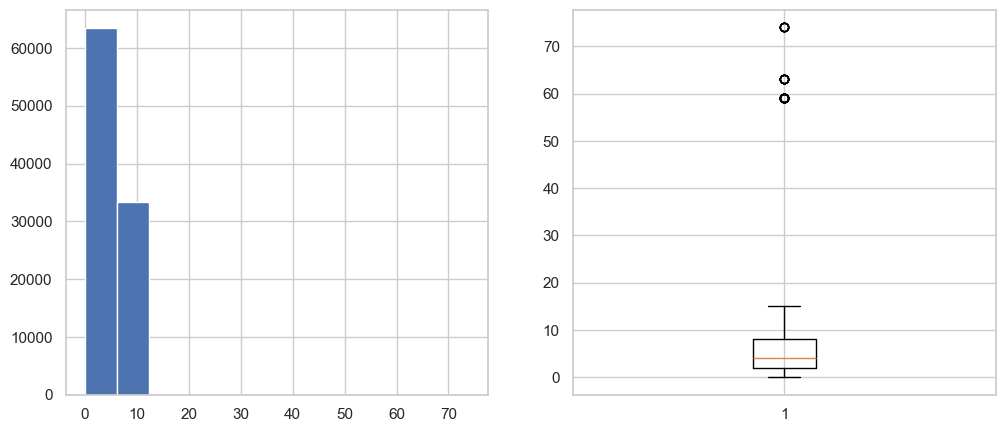

In [138]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Num_Credit_Inquiries'], bins=12)
ax2.boxplot(credit_df['Num_Credit_Inquiries'])
plt.show()

**Выводы по признаку Num_Credit_Inquiries**
- Признак очищен от некорректных значений.
- Пропуски и исправления значений выполнены в соответствии с внутренней согласованностью данных по клиентам.
- В распределении признака присутствуют выбросы.
- Выбросы рекомендуется не удалять, поскольку большое количество запросов кредитной истории для одного клиента может быть валидным и отражать его реальную кредитную активность.

In [139]:
credit_df['Credit_Mix'].describe()

count        96805
unique           4
top       Standard
freq         35332
Name: Credit_Mix, dtype: object

In [140]:
credit_df['Credit_Mix'].unique()

array(['_', 'Good', 'Standard', 'Bad'], dtype=object)

In [141]:
credit_df['Credit_Mix'] = credit_df['Credit_Mix'].str.replace('_', 'Not Known')
credit_df['Credit_Mix'] = credit_df['Credit_Mix'].fillna('Not Know')

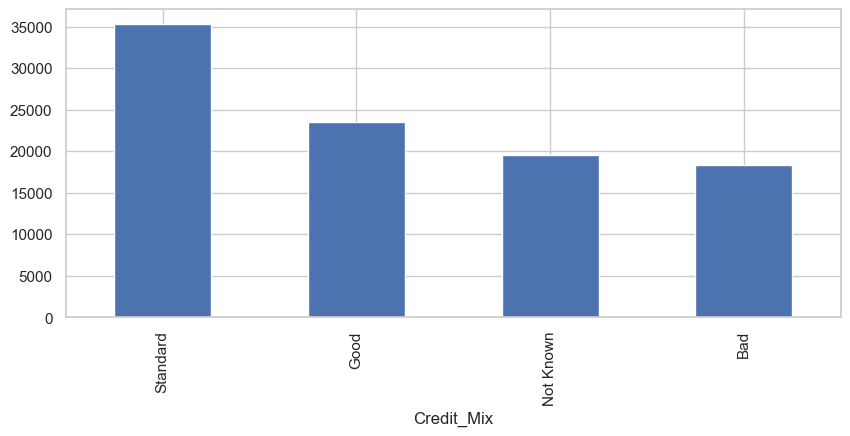

In [142]:
credit_mix = credit_df['Credit_Mix'].value_counts()
credit_mix.plot(kind='bar', figsize=(10, 4))
plt.show()

**Выводы по признаку Credit_Mix**
- Признак очищен от некорректных значений.
- Пропуски и исправления значений выполнены в соответствии с внутренней согласованностью данных по клиентам.
- Заглушка "_" была заменена на Not Known
- Пропуски также были заполнены Not Known

In [143]:
credit_df['Outstanding_Debt'].describe()

count      96805
unique     13095
top       1151.7
freq          23
Name: Outstanding_Debt, dtype: object

In [144]:
credit_df['Outstanding_Debt'] = credit_df['Outstanding_Debt'].str.replace('_', '')
credit_df['Outstanding_Debt'] = credit_df['Outstanding_Debt'].astype('float')

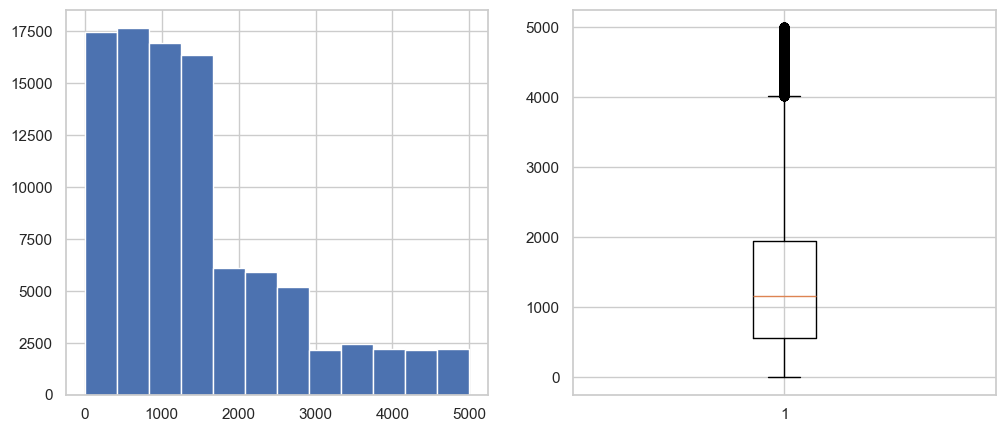

In [145]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Outstanding_Debt'], bins=12)
ax2.boxplot(credit_df['Outstanding_Debt'])
plt.show()

**Выводы по признаку Outstanding debt**
- Исправлены некоректные значения
- Изменен тип данных на float
- Распределение имеет левую ассиметрию
- Большая часть клиентов имеет небольшую задолженность

In [146]:
credit_df['Credit_Utilization_Ratio'].describe()

count    96805.000000
mean        32.286097
std          5.118026
min         20.000000
25%         28.054565
50%         32.307019
75%         36.501062
max         50.000000
Name: Credit_Utilization_Ratio, dtype: float64

In [147]:
credit_df['Credit_Utilization_Ratio'].isna().sum()

np.int64(0)

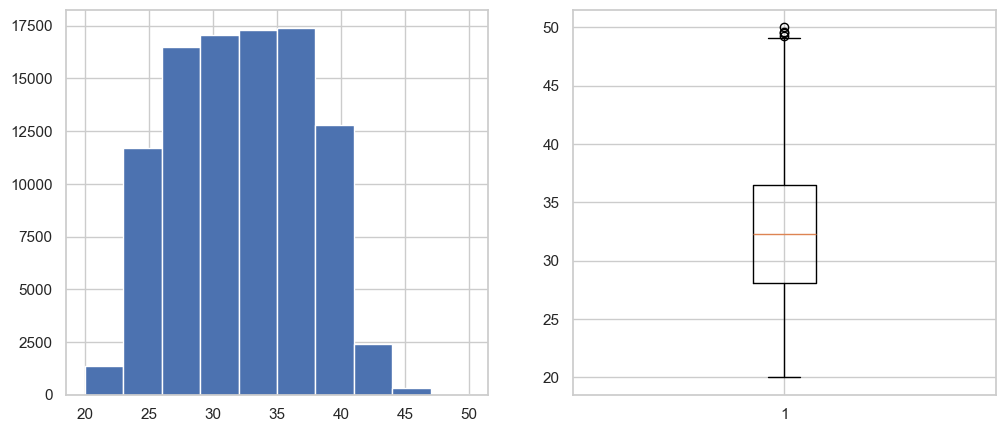

In [148]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Credit_Utilization_Ratio'])
ax2.boxplot(credit_df['Credit_Utilization_Ratio'])
plt.show()

**Выводы по признаку Credit_Utilization_Ratio**
- данные признака корректны
- распределение близко к нормальному
- большая часть клиентов использует около 30% кредитного лимита
- ни один клиент не использует кредитный лимит более, чем на 50%

In [149]:
credit_df['Credit_History_Age'].isna().sum()

np.int64(8747)

In [150]:
credit_df['Credit_History_Age'].describe()

count                      88058
unique                       404
top       15 Years and 11 Months
freq                         435
Name: Credit_History_Age, dtype: object

In [151]:
credit_df['Years'] = (
    credit_df['Credit_History_Age']
    .str.extract(r'(\d+)\s+Years')[0]
    .astype(float)
)

credit_df['Months'] = (
    credit_df['Credit_History_Age']
    .str.extract(r'(\d+)\s+Months')[0]
    .astype(float)
)

In [152]:
credit_df['Credit_History_Age_Months'] = (
    credit_df['Years'] * 12 +
    credit_df['Months']
)
credit_df.drop('Credit_History_Age', inplace=True, axis=1)

In [153]:
credit_df['Credit_History_Age_Months'] = (
    credit_df.groupby('Customer_ID')['Credit_History_Age_Months']
    .transform(lambda x: x.fillna(x.median()))
)

In [193]:
credit_df.drop(['Years', 'Months'], axis=1, inplace=True)

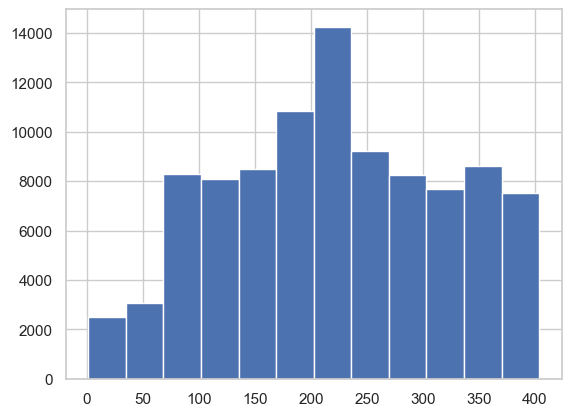

In [154]:
plt.hist(credit_df['Credit_History_Age_Months'], bins=12)
plt.show()

In [155]:
credit_df['Credit_History_Age_Months'].isna().sum()

np.int64(0)

**Выводы по признаку Credit_History_Age**
- данные признака корректны
- на основе признака был создан новый **Credit_History_Age_Months**, отражающий суммарное количество месяцев крединтной истории без разбивки по годам
- пропуски были заполнены мединой признака по каждому клиенту

In [156]:
credit_df['Payment_of_Min_Amount'].describe()

count     96805
unique        3
top         Yes
freq      50684
Name: Payment_of_Min_Amount, dtype: object

In [157]:
credit_df['Payment_of_Min_Amount'].isna().sum()

np.int64(0)

In [158]:
credit_df['Payment_of_Min_Amount'].unique()

array(['No', 'NM', 'Yes'], dtype=object)

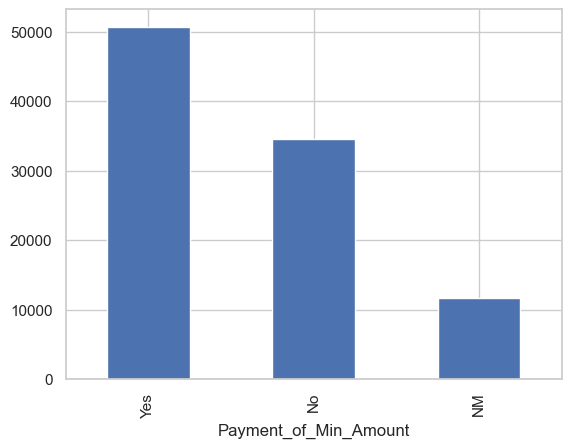

In [159]:
credit_df['Payment_of_Min_Amount'].value_counts().plot(kind='bar')
plt.show()

**выводы по признаку Payment_of_Min_Amount**
- Большая часть клиентво оплачивает только минимальную сумму 
- Причина появления NM неизвестна, так как это может быть и неоплата кредита и сбой в базе данных

In [160]:
credit_df['Total_EMI_per_month'].describe()

count    96805.000000
mean      1399.695065
std       8291.483180
min          0.000000
25%         30.453014
50%         69.318349
75%        161.487532
max      82331.000000
Name: Total_EMI_per_month, dtype: float64

In [161]:
credit_df['Total_EMI_per_month'].isna().sum()

np.int64(0)

**выводы по признаку Total_EMI_per_month**
- Пропусков нет
- Данные валидны, но малоинформативны
- Для оценки крединтного скоринга нужно создать дополнительные признаки: Платеж по кридут/ежемесячный доход или связь с процентом по использованию кредита
- Требуется создать дополнительные признаки, чтобы выявить взаимосвязи внутри датасета

In [162]:
credit_df['Amount_invested_monthly'].describe()

count         92477
unique        88162
top       __10000__
freq           4156
Name: Amount_invested_monthly, dtype: object

In [163]:
credit_df['Amount_invested_monthly'] = credit_df['Amount_invested_monthly'].str.replace('_', '')
credit_df['Amount_invested_monthly'] = credit_df['Amount_invested_monthly'].str.replace('__', '')
credit_df['Amount_invested_monthly'] = credit_df['Amount_invested_monthly'].astype('float')

In [164]:
credit_df['Amount_invested_monthly'].describe()

count    92477.000000
mean       636.436983
std       2040.556342
min          0.000000
25%         74.573916
50%        136.061460
75%        266.234685
max      10000.000000
Name: Amount_invested_monthly, dtype: float64

In [165]:
credit_df['Amount_invested_monthly'] = (
    credit_df.groupby('Customer_ID')['Amount_invested_monthly']
    .transform(lambda x: x.fillna(x.median()))
)

In [166]:
credit_df['Amount_invested_monthly'].isna().sum()

np.int64(0)

**выводы по признаку Amount_invested_monthly**
- Пропуски заполнены медианой по каждому клиенту
- Большая часть клиентов инвестирует до 300 долларов в месяц
- Небольшая часть клиентов инвестирует свыше этой суммы

In [167]:
credit_df['Payment_Behaviour'].describe()

count                              96805
unique                                 7
top       Low_spent_Small_value_payments
freq                               24716
Name: Payment_Behaviour, dtype: object

In [168]:
credit_df['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments', 'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', '!@9#%8',
       'High_spent_Large_value_payments',
       'Low_spent_Medium_value_payments'], dtype=object)

In [169]:
invalid_mask = credit_df['Payment_Behaviour'] == '!@9#%8'

client_mode = (
    credit_df.loc[~invalid_mask]
    .groupby('Customer_ID')['Payment_Behaviour']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

credit_df.loc[invalid_mask, 'Payment_Behaviour'] = (
    credit_df.loc[invalid_mask, 'Customer_ID'].map(client_mode)
)

In [170]:
credit_df['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments', 'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Medium_value_payments'], dtype=object)

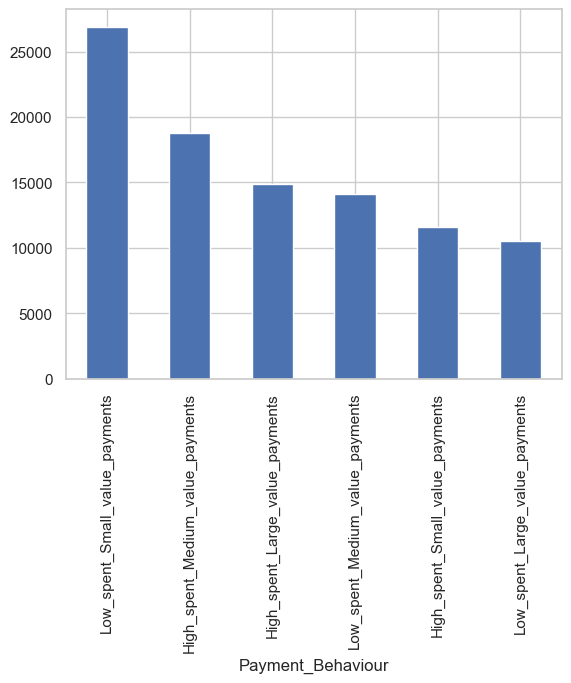

In [171]:
credit_df['Payment_Behaviour'].value_counts().plot(kind='bar')
plt.show()

**Выводы по payment behavior**
- самая большая группа - низкие доходы, маленькие расходы
- рекомендуется создать дополнительные признаки Spent, Payments

In [172]:
credit_df['Monthly_Balance'].describe()

count                                95631
unique                               95623
top       __-333333333333333333333333333__
freq                                     9
Name: Monthly_Balance, dtype: object

In [173]:
credit_df['Monthly_Balance'] = credit_df['Monthly_Balance'].str.replace('_', '')
credit_df['Monthly_Balance'] = credit_df['Monthly_Balance'].str.replace('__', '')
credit_df['Monthly_Balance'] = credit_df['Monthly_Balance'].astype('float')

In [174]:
credit_df['Monthly_Balance'].describe()

count    9.401100e+04
mean    -3.191116e+22
std      3.261311e+24
min     -3.333333e+26
25%      2.699777e+02
50%      3.365451e+02
75%      4.698745e+02
max      1.602041e+03
Name: Monthly_Balance, dtype: float64

In [175]:
credit_df['Monthly_Balance'] = (
    credit_df.groupby('Customer_ID')['Monthly_Balance']
    .transform(lambda x: x.fillna(x.median()))
)

In [176]:
credit_df[credit_df['Monthly_Balance'] < 0]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Years,Months,Credit_History_Age_Months
ID,,,,,,,,,,,,,,,,,,,,,
0x367f,CUS_0x9885,February,Paul Dayl,17,186-49-9679,Developer,41086.400,3660.866667,3,4,...,34.826541,Yes,145.544320,201.142993,Low_spent_Medium_value_payments,-3.333333e+26,Standard,11.0,6.0,138.0
0xaf63,CUS_0x5a90,February,Scuffhamq,45,264-53-1943,Engineer,29728.310,2551.359167,3,4,...,38.198076,No,34.496445,198.611513,Low_spent_Large_value_payments,-3.333333e+26,Good,31.0,9.0,381.0
0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.930,2572.410833,1,6,...,40.634250,No,43.727774,79.071807,High_spent_Small_value_payments,-3.333333e+26,Standard,19.0,5.0,233.0
0xe66c,CUS_0x85e9,March,Anna Driveri,45,288-62-7562,Musician,20929.295,1704.107917,5,3,...,33.943626,No,13798.000000,220.304552,Low_spent_Small_value_payments,-3.333333e+26,Standard,21.0,7.0,259.0
0xf84c,CUS_0x2b77,July,Longstretho,21,006-36-0111,Doctor,15167.620,1471.968333,4,5,...,28.541848,NM,9.930809,128.875872,Low_spent_Small_value_payments,-3.333333e+26,Standard,NaN,NaN,327.5
0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.680,7811.223333,3,4,...,39.089475,Yes,54.219664,308.939961,High_spent_Large_value_payments,-3.333333e+26,Standard,20.0,10.0,250.0
0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.590,5080.382500,3,4,...,29.878716,Yes,61.525140,394.893957,Low_spent_Small_value_payments,-3.333333e+26,Standard,12.0,11.0,155.0
0x1fbd8,CUS_0x41bf,July,Doeringq,44,693-64-7611,Journalist,61990.520,4900.876667,10,10,...,37.718591,NM,355.143396,194.283488,Low_spent_Small_value_payments,-3.333333e+26,Standard,13.0,8.0,164.0
0x1fdd1,CUS_0x2f7e,August,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.040,10635.420000,4,7,...,28.442867,No,167.043910,549.766139,Low_spent_Medium_value_payments,-3.333333e+26,Poor,31.0,9.0,381.0


Значение '-3.333333e+26' повторяется у нескольких клиентов. Это ошибка. Рассмотрим двух случайных клиентов с этой ошибкой.

In [177]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x2f7e']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Years,Months,Credit_History_Age_Months
ID,,,,,,,,,,,,,,,,,,,,,
0x1fdca,CUS_0x2f7e,January,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,41.435986,No,167.04391,238.327461,High_spent_Large_value_payments,8.981706e+02,Standard,31.0,2.0,374.0
0x1fdcb,CUS_0x2f7e,February,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,29.813305,NM,167.04391,147.775984,High_spent_Large_value_payments,9.887221e+02,Standard,31.0,3.0,375.0
0x1fdcc,CUS_0x2f7e,March,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,35.866745,No,167.04391,269.008584,Low_spent_Large_value_payments,8.974895e+02,Standard,31.0,4.0,376.0
0x1fdcd,CUS_0x2f7e,April,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,30.184253,No,167.04391,232.432857,High_spent_Large_value_payments,9.040652e+02,Standard,31.0,5.0,377.0
0x1fdce,CUS_0x2f7e,May,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,30.221823,NM,167.04391,437.113824,High_spent_Medium_value_payments,7.093843e+02,Standard,31.0,6.0,378.0
0x1fdcf,CUS_0x2f7e,June,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,26.578597,NM,167.04391,498.387992,Low_spent_Medium_value_payments,6.781101e+02,Standard,31.0,7.0,379.0
0x1fdd0,CUS_0x2f7e,July,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,30.875534,No,167.04391,296.827183,High_spent_Small_value_payments,8.596709e+02,Standard,31.0,8.0,380.0
0x1fdd1,CUS_0x2f7e,August,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.42,4,7,...,28.442867,No,167.04391,549.766139,Low_spent_Medium_value_payments,-3.333333e+26,Poor,31.0,9.0,381.0


In [178]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x9885']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Years,Months,Credit_History_Age_Months
ID,,,,,,,,,,,,,,,,,,,,,
0x367e,CUS_0x9885,January,Paul Dayl,16,186-49-9679,Developer,41086.4,3660.866667,3,4,...,30.909275,Yes,145.54432,47.145533,High_spent_Small_value_payments,4.233968e+02,Standard,11.0,5.0,137.0
0x367f,CUS_0x9885,February,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,34.826541,Yes,145.54432,201.142993,Low_spent_Medium_value_payments,-3.333333e+26,Standard,11.0,6.0,138.0
0x3680,CUS_0x9885,March,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,38.450201,Yes,145.54432,232.130785,Low_spent_Small_value_payments,2.784116e+02,Standard,11.0,7.0,139.0
0x3681,CUS_0x9885,April,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,27.084247,Yes,145.54432,49.985436,High_spent_Medium_value_payments,4.205569e+02,Standard,11.0,8.0,140.0
0x3682,CUS_0x9885,May,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,40.206154,Yes,145.54432,439.254486,Low_spent_Small_value_payments,7.128786e+01,Standard,11.0,9.0,141.0
0x3683,CUS_0x9885,June,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,24.689003,NM,145.54432,97.258469,High_spent_Small_value_payments,3.832839e+02,Standard,11.0,10.0,142.0
0x3684,CUS_0x9885,July,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,31.127866,Yes,145.54432,251.535315,High_spent_Small_value_payments,2.290070e+02,Standard,11.0,11.0,143.0
0x3685,CUS_0x9885,August,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,35.211255,Yes,145.54432,116.511281,High_spent_Small_value_payments,3.740311e+02,Standard,12.0,0.0,144.0


Это очевидная ошибка, заменим ее на медиану по каждому клиенту.

In [179]:
mask = credit_df['Monthly_Balance'] < 0

client_median = (
    credit_df.groupby('Customer_ID')['Monthly_Balance']
    .transform('median')
)

credit_df.loc[mask, 'Monthly_Balance'] = client_median[mask]

In [180]:
credit_df['Monthly_Balance'] = (
    credit_df.groupby('Customer_ID')['Monthly_Balance']
    .transform(lambda x: x.fillna(x.median()))
)

In [181]:
credit_df['Monthly_Balance'].isna().sum()

np.int64(1648)

In [182]:
credit_df['Monthly_Balance'] = (
    credit_df.groupby('Customer_ID')['Monthly_Balance']
    .transform(lambda x: x.fillna(x.median()))
)

credit_df['Monthly_Balance'] = (
    credit_df['Monthly_Balance']
    .fillna(credit_df['Monthly_Balance'].median())
)

In [183]:
credit_df['Monthly_Balance'].isna().sum()

np.int64(0)

In [184]:
credit_df['Monthly_Balance'].describe()

count    96805.000000
mean       402.084170
std        212.604635
min          0.007760
25%        271.226487
50%        337.073894
75%        467.992330
max       1602.040519
Name: Monthly_Balance, dtype: float64

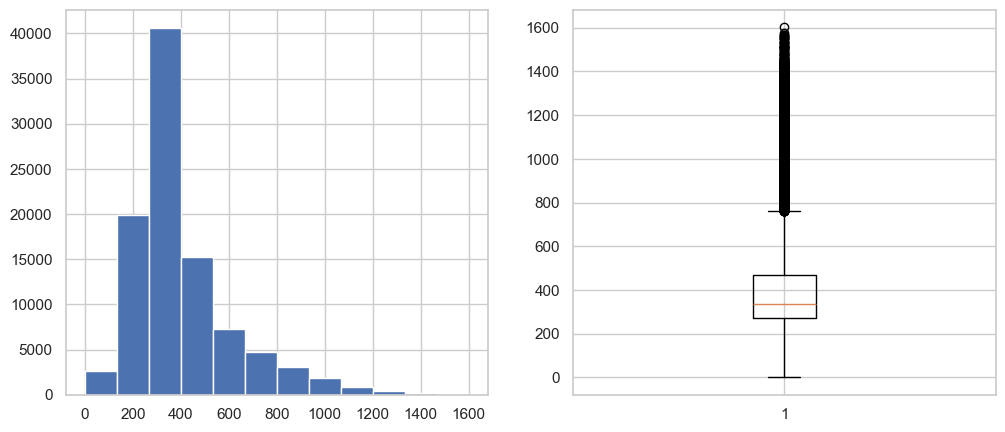

In [185]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Monthly_Balance'], bins=12)
ax2.boxplot(credit_df['Monthly_Balance'])
plt.show()

**выводы по признаку Monthly Balance**
- есть небольшая ассметрия характерная для такого типа данных
- в датасете большое количество клиентов с небольшим ежемесячным балансом
- средний баланс в датасете 403 доллара

In [186]:
credit_df['Credit_Score'].unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

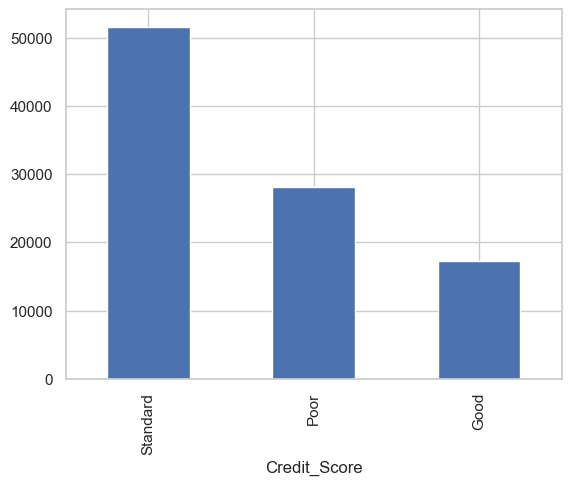

In [187]:
credit_df['Credit_Score'].value_counts().plot(kind='bar')
plt.show()

**выводы по признаку Credit Score**
- Большая часть клиентво имеет оценку Standard
- Небольшое количество клиентов имеет оценку Good
- В датафреме существует дисбаланс классов

In [188]:
credit_df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Years,Months,Credit_History_Age_Months
count,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,96805.000000,88058.000000,88058.000000,96805.000000
mean,33.330334,50553.541390,4202.293086,5.368969,5.534662,14.531285,3.533247,21.068788,13.322442,10.481873,4.959672,1426.058045,32.286097,1399.695065,616.529251,402.084170,17.969702,5.596550,221.234600
std,10.771426,38305.707829,3187.924979,2.592616,2.067807,8.735904,2.445814,14.858024,6.289365,6.654464,3.720883,1155.715611,5.118026,8291.483180,1997.157401,212.604635,8.318561,3.450209,99.646117
min,14.000000,7005.930000,303.645417,0.000000,1.000000,1.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760,0.000000,0.000000,1.000000
25%,24.000000,19370.480000,1628.847500,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.390000,2.000000,565.280000,28.054565,30.453014,75.401061,271.226487,12.000000,3.000000,145.000000
50%,33.000000,37045.600000,3097.813333,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.410000,4.000000,1165.700000,32.307019,69.318349,136.392112,337.073894,18.000000,5.000000,219.000000
75%,42.000000,71716.560000,5967.748333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.840000,8.000000,1946.810000,36.501062,161.487532,263.760637,467.992330,25.000000,9.000000,302.000000
max,56.000000,179987.280000,15204.633333,18.000000,17.000000,34.000000,9.000000,67.000000,28.000000,36.970000,74.000000,4998.070000,50.000000,82331.000000,10000.000000,1602.040519,33.000000,11.000000,404.000000


In [189]:
credit_df.isna().sum()

Customer_ID                     0
Month                           0
Name                            0
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary           0
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                    0
Delay_from_due_date             0
Num_of_Delayed_Payment          0
Changed_Credit_Limit            0
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance                 0
Credit_Score                    0
Years                        8747
Months                       8747
Credit_History_Age_Months       0
dtype: int64

In [190]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96805 entries, 0x1602 to 0x25fed
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                96805 non-null  object 
 1   Month                      96805 non-null  object 
 2   Name                       96805 non-null  object 
 3   Age                        96805 non-null  int64  
 4   SSN                        96805 non-null  object 
 5   Occupation                 96805 non-null  object 
 6   Annual_Income              96805 non-null  float64
 7   Monthly_Inhand_Salary      96805 non-null  float64
 8   Num_Bank_Accounts          96805 non-null  int64  
 9   Num_Credit_Card            96805 non-null  int64  
 10  Interest_Rate              96805 non-null  int64  
 11  Num_of_Loan                96805 non-null  int32  
 12  Type_of_Loan               96805 non-null  object 
 13  Delay_from_due_date        96805 non-null  i

### Выводы:

- изменены типы данных столбцов: 